# Deep Multimodal Fraud Detection - ResNet-18

Late fusion: CNN image branch + tabular MLP branch, combined via fusion head.
Structured identically to notebooks 11, 12, 15, and 16.

4 experiments (2×2 ablation):
- **A** Raw features, normal training
- **B** Raw features, WeightedRandomSampler
- **C** Engineered features, normal training
- **D** Engineered features, WeightedRandomSampler




In [1]:
import sys, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sys.path.insert(0, r"C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\src")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

from multimodal_utils import (
    MultimodalFraudDetector,
    engineer_features, validate_features,
    TAB_RAW, TAB_ALL_FE, TARGET_COL,
    fit_scaler, build_dataloaders,
    make_loss_fn, fit_model, predict_probs,
    subgroup_by_combo,
)

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

SEED   = 42
set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}  |  PyTorch {torch.__version__}")


Device : cpu  |  PyTorch 2.11.0+cpu


In [2]:
PROJECT_ROOT = Path().resolve().parent
DATA_DIR     = PROJECT_ROOT / "data" / "processed"

BACKBONE = "resnet18"

TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"
VAL_CSV   = DATA_DIR / "mm_val_mixed_all_group_test.csv"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"

BATCH_SIZE      = 32
NUM_WORKERS     = 0
STAGE1_EPOCHS   = 5;   STAGE1_LR   = 1e-3;  STAGE1_PATIENCE = 5
STAGE2_EPOCHS   = 20;  BACKBONE_LR = 1e-5;  HEAD_LR         = 1e-4
STAGE2_PATIENCE = 6

RESULTS_BASE = PROJECT_ROOT / "notebook" / "results" / f"mm_deep_{BACKBONE}"
EXP_DIRS = {
    "A_raw_normal":  RESULTS_BASE / "A_raw_normal",
    "B_raw_sampler": RESULTS_BASE / "B_raw_sampler",
    "C_fe_normal":   RESULTS_BASE / "C_fe_normal",
    "D_fe_sampler":  RESULTS_BASE / "D_fe_sampler",
}
for d in EXP_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

COMBO_COLOURS = {"tab0_img0":"#4C72B0","tab1_img1":"#C44E52",
                 "tab1_img0":"#DD8452","tab0_img1":"#55A868"}

print(f"Backbone    : {BACKBONE}")
print(f"Results base: {RESULTS_BASE}")


Backbone    : resnet18
Results base: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18


# Deep multimodal baseline — ResNet-18


In [3]:
train_raw = pd.read_csv(TRAIN_CSV)
val_raw   = pd.read_csv(VAL_CSV)
test_raw  = pd.read_csv(TEST_CSV)

train_fe = engineer_features(train_raw)
val_fe   = engineer_features(val_raw)
test_fe  = engineer_features(test_raw)

validate_features(TAB_RAW)
validate_features(TAB_ALL_FE)
print("Feature validation passed — no label leakage.")

scaler_raw = fit_scaler(train_raw, TAB_RAW)
scaler_fe  = fit_scaler(train_fe,  TAB_ALL_FE)

print(f"\nTrain: {len(train_raw):,} | Val: {len(val_raw):,} | Test: {len(test_raw):,}")
print(f"Raw features ({len(TAB_RAW)}): {TAB_RAW}")
print(f"Engineered features ({len(TAB_ALL_FE)}): {TAB_ALL_FE}")
print("\nTrain class counts:")
print(train_raw[TARGET_COL].value_counts())


Feature validation passed — 7 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — no label leakage.
Feature validation passed — 7 features, no leakage.
Scaler fitted on 7 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Feature validation passed — 12 features, no leakage.
Scaler fitted on 12 features: ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed']

Train: 7,182 | Val: 1,508 | Test: 1,474
Raw features (7): ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud']
Engineered features (12): ['tab_type', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalance

## Imbalance analysis

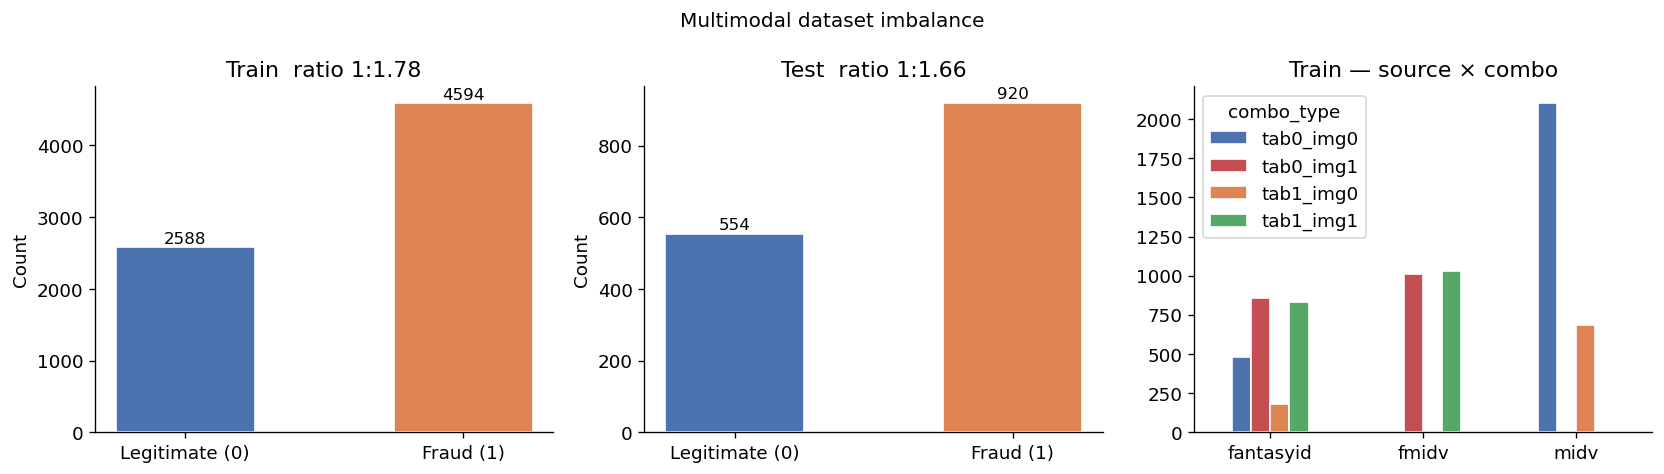

pos_weight = 2588/4594 = 0.563  (DOWN-weights fraud = majority class)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, df) in zip(axes[:2], [("Train",train_raw),("Test",test_raw)]):
    counts = df[TARGET_COL].value_counts().sort_index()
    bars = ax.bar(["Legitimate (0)","Fraud (1)"], counts.values,
                  color=["#4C72B0","#DD8452"], edgecolor="white", width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                str(val), ha="center", va="bottom", fontsize=10)
    ratio = counts.get(1,0)/max(counts.get(0,1),1)
    ax.set_title(f"{name}  ratio 1:{ratio:.2f}"); ax.set_ylabel("Count")
    ax.spines[["top","right"]].set_visible(False)
if "img_source_dataset" in train_raw.columns:
    pd.crosstab(train_raw["img_source_dataset"],
                train_raw["combo_type"]).plot(
        kind="bar", ax=axes[2],
        color=list(COMBO_COLOURS.values()), edgecolor="white")
    axes[2].set_title("Train — source × combo"); axes[2].set_xlabel("")
    axes[2].tick_params(axis="x", rotation=0)
    axes[2].spines[["top","right"]].set_visible(False)
fig.suptitle("Multimodal dataset imbalance", fontsize=12)
fig.tight_layout(); plt.show()
n0 = (train_raw[TARGET_COL]==0).sum(); n1 = (train_raw[TARGET_COL]==1).sum()
print(f"pos_weight = {n0}/{n1} = {n0/n1:.3f}  (DOWN-weights fraud = majority class)")


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, auc as sk_auc,
    confusion_matrix, ConfusionMatrixDisplay,
)

from cost_config import FN_COST, FP_COST

def evaluate_mm_model(y_true, y_prob, split_name="split", threshold=0.5):
    """Mirrors evaluate_model() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "split":     split_name,
        "accuracy":  float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_true, y_prob)),
        "pr_auc":    float(average_precision_score(y_true, y_prob)),
    }
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n=== {split_name.upper()} ===")
    for k, v in metrics.items():
        if k != "split": print(f"{k}: {v:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def search_thresholds_mm(y_true, y_prob,
                          thresholds=np.arange(0.10, 1.00, 0.05)):
    """Mirrors search_thresholds() from tabular utils."""
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold":       round(float(t), 4),
            "precision":       float(precision_score(y_true, y_pred, zero_division=0)),
            "recall":          float(recall_score(y_true,    y_pred, zero_division=0)),
            "f1":              float(f1_score(y_true,        y_pred, zero_division=0)),
            "predicted_fraud": int(y_pred.sum()),
        })
    return pd.DataFrame(rows)

def compute_cost_table_mm(threshold_results, y_val_true,
                           fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_cost_table() from tabular utils."""
    n_pos = int((y_val_true == 1).sum())
    n_neg = int((y_val_true == 0).sum())
    rows = []
    for _, row in threshold_results.iterrows():
        tp = round(row["recall"] * n_pos)
        fn = n_pos - tp
        fp = row["predicted_fraud"] - tp
        tn = n_neg - fp
        rows.append({
            "threshold":       row["threshold"],
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "precision":       row["precision"],
            "recall":          row["recall"],
            "f1":              row["f1"],
            "predicted_fraud": row["predicted_fraud"],
            "expected_cost":   int(fn * fn_cost + fp * fp_cost),
        })
    return pd.DataFrame(rows).sort_values("expected_cost").reset_index(drop=True)

def evaluate_mm_with_threshold(y_true, y_prob, threshold):
    """Mirrors evaluate_with_threshold() from tabular utils."""
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    metrics = {
        "threshold": float(threshold),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true,    y_pred, zero_division=0)),
        "f1":        float(f1_score(y_true,        y_pred, zero_division=0)),
    }
    print(f"\nTuned threshold: {threshold}")
    print(f"Precision: {metrics['precision']:.6f}")
    print(f"Recall:    {metrics['recall']:.6f}")
    print(f"F1:        {metrics['f1']:.6f}")
    print("\nConfusion matrix:"); print(cm)
    return metrics, cm

def compute_expected_cost_from_cm(cm, fn_cost=FN_COST, fp_cost=FP_COST):
    """Mirrors compute_expected_cost_from_cm() from tabular utils."""
    tn, fp, fn, tp = cm.ravel()
    return {"tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "expected_cost": int(fn * fn_cost + fp * fp_cost)}

def save_mm_experiment_outputs(results_dir, test_y_true, test_y_prob,
                                threshold_results, cost_df,
                                tuned_metrics, tuned_cm,
                                val_metrics, test_metrics, prefix,
                                subgroup_df=None):
    """Mirrors save_experiment_outputs() from tabular utils."""
    from pathlib import Path
    results_dir = Path(results_dir)
    pred_df = pd.DataFrame({"y_true": test_y_true, "y_prob": test_y_prob})
    pred_df["y_pred"] = (pred_df["y_prob"] >= tuned_metrics["threshold"]).astype(int)
    pred_df.to_csv(results_dir / "test_predictions.csv", index=False)
    threshold_results.to_csv(results_dir / f"{prefix}_threshold_results.csv", index=False)
    cost_df.to_csv(results_dir / f"{prefix}_cost_results.csv", index=False)
    pd.DataFrame([tuned_metrics]).to_csv(results_dir / f"{prefix}_tuned_metrics.csv", index=False)
    pd.DataFrame(tuned_cm, index=["true_0","true_1"],
                 columns=["pred_0","pred_1"]).to_csv(
        results_dir / f"{prefix}_tuned_cm.csv")
    pd.DataFrame([val_metrics, test_metrics]).to_csv(
        results_dir / f"{prefix}_metrics_summary.csv", index=False)
    if subgroup_df is not None:
        subgroup_df.to_csv(results_dir / "subgroup_combo_type.csv", index=False)

def plot_model_diagnostics_pretty(cm, threshold_results, cost_df, model_name,
                                   fn_cost=FN_COST, fp_cost=FP_COST, save_path=None):
    """Identical to notebooks 11, 12, 15, 16."""
    cm = np.asarray(cm).astype(int)
    threshold_df   = threshold_results.sort_values("threshold")
    cost_df_sorted = cost_df.sort_values("threshold")
    best_row            = cost_df.loc[cost_df["expected_cost"].idxmin()]
    best_threshold      = float(best_row["threshold"])
    best_validation_cost = float(best_row["expected_cost"])
    tn, fp, fn, tp = cm.ravel()
    test_expected_cost  = fn * fn_cost + fp * fp_cost

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), constrained_layout=True)
    fig.patch.set_facecolor("white")

    ax = axes[0]
    cm_for_color = np.maximum(cm, 1)
    norm = LogNorm(vmin=1, vmax=cm_for_color.max())
    im = ax.imshow(cm_for_color, cmap="Blues", norm=norm)
    ax.set_title("Tuned test confusion matrix", fontsize=12, pad=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Legit","Fraud"]); ax.set_yticklabels(["Legit","Fraud"])
    ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
    for i in range(2):
        for j in range(2):
            value = cm[i,j]; rgba = im.cmap(norm(cm_for_color[i,j]))
            lum = 0.299*rgba[0]+0.587*rgba[1]+0.114*rgba[2]
            ax.text(j, i, f"{value:,}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if lum < 0.45 else "#08306b")
    for sp in ax.spines.values(): sp.set_visible(False)

    ax = axes[1]
    ax.plot(threshold_df["threshold"], threshold_df["precision"], linewidth=2.2, label="Precision")
    ax.plot(threshold_df["threshold"], threshold_df["recall"],    linewidth=2.2, label="Recall")
    ax.plot(threshold_df["threshold"], threshold_df["f1"],        linewidth=2.2, label="F1")
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.text(0.98, 0.95, f"Best threshold = {best_threshold:.2f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set_title("Validation metrics by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.25); ax.legend(frameon=False, loc="lower left")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

    ax = axes[2]
    ax.plot(cost_df_sorted["threshold"], cost_df_sorted["expected_cost"],
            linewidth=2.2, marker="o", markersize=4)
    ax.axvline(best_threshold, linestyle="--", linewidth=1.8, color="black", alpha=0.7)
    ax.scatter(best_threshold, best_validation_cost, s=80, color="black", zorder=5)
    ax.annotate(f"Min cost: ${best_validation_cost/1_000_000:.2f}M",
                xy=(best_threshold, best_validation_cost), xytext=(18,18),
                textcoords="offset points", fontsize=10,
                arrowprops=dict(arrowstyle="->", linewidth=1, color="black"),
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
    ax.set_title("Validation expected cost by threshold", fontsize=12, pad=12)
    ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.suptitle(f"{model_name} | Tuned test cost: ${test_expected_cost/1_000_000:.2f}M",
                 fontsize=15, fontweight="bold")
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

print("All helper functions defined.")


All helper functions defined.


## 1. A_raw_normal

Raw features, no WeightedRandomSampler. Direct baseline.

In [6]:
results_dir = EXP_DIRS["A_raw_normal"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_A_raw_normal, val_loader_A_raw_normal, test_loader_A_raw_normal = build_dataloaders(
    train_raw, val_raw, test_raw,
    scaler_raw, TAB_RAW,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
loss_fn_A_raw_normal = make_loss_fn(train_raw, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved A_raw_normal model...")
    model_A_raw_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=False).to(device)
    model_A_raw_normal.load_state_dict(torch.load(model_path, map_location=device))
    model_A_raw_normal.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training A_raw_normal model...")
    model_A_raw_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=True).to(device)
    model_A_raw_normal.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_A_raw_normal.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_A_raw_normal, h_s1 = fit_model(
        model_A_raw_normal, train_loader_A_raw_normal, val_loader_A_raw_normal, loss_fn_A_raw_normal,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_A_raw_normal.unfreeze_backbone()
    bp = [p for n, p in model_A_raw_normal.named_parameters() if "image_backbone" not in n]
    hp = list(model_A_raw_normal.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_A_raw_normal, h_s2 = fit_model(
        model_A_raw_normal, train_loader_A_raw_normal, val_loader_A_raw_normal, loss_fn_A_raw_normal,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\A_raw_normal\stage2_best.pt
Model exists: True
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved A_raw_normal model...
MultimodalFraudDetector | backbone=resnet18 | tab_dim=7 | fusion_dim=256 | params=11,409,217
Model loaded successfully.


In [7]:
val_y_A_raw_normal,  val_p_A_raw_normal  = predict_probs(model_A_raw_normal, val_loader_A_raw_normal,  device)
test_y_A_raw_normal, test_p_A_raw_normal = predict_probs(model_A_raw_normal, test_loader_A_raw_normal, device)

val_metrics_A_raw_normal,  val_cm_A_raw_normal  = evaluate_mm_model(
    val_y_A_raw_normal,  val_p_A_raw_normal,  split_name="validation_A_raw_normal")
test_metrics_A_raw_normal, test_cm_A_raw_normal = evaluate_mm_model(
    test_y_A_raw_normal, test_p_A_raw_normal, split_name="test_A_raw_normal")



=== VALIDATION_A_RAW_NORMAL ===
accuracy: 0.853448
precision: 0.938702
recall: 0.821241
f1: 0.876052
roc_auc: 0.961381
pr_auc: 0.977084

Confusion matrix:
[[506  51]
 [170 781]]

=== TEST_A_RAW_NORMAL ===
accuracy: 0.864315
precision: 0.953401
recall: 0.822826
f1: 0.883314
roc_auc: 0.967052
pr_auc: 0.980079

Confusion matrix:
[[517  37]
 [163 757]]


The A_RAW_NORMAL multimodal ResNet model achieved a test F1-score of 0.8833, with precision of 0.9534 and recall of 0.8228. It detected 757 fraud cases and missed 163, while producing only 37 false positives. Compared with the image-only ResNet baseline, the multimodal model substantially improved ROC-AUC and PR-AUC, showing that raw tabular features add useful information to the image branch.

### Threshold tuning - A_raw_normal

Cost-based tuning on validation set.

In [8]:
threshold_results_A_raw_normal = search_thresholds_mm(val_y_A_raw_normal, val_p_A_raw_normal)
print(threshold_results_A_raw_normal)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.824715  0.989485  0.899618             1141
1        0.15   0.860166  0.983176  0.917566             1087
2        0.20   0.874166  0.964248  0.917000             1049
3        0.25   0.892505  0.951630  0.921120             1014
4        0.30   0.900101  0.937960  0.918641              991
5        0.35   0.912500  0.921136  0.916797              960
6        0.40   0.924918  0.893796  0.909091              919
7        0.45   0.929465  0.859096  0.892896              879
8        0.50   0.938702  0.821241  0.876052              832
9        0.55   0.956863  0.769716  0.853147              765
10       0.60   0.982430  0.705573  0.821297              683
11       0.65   0.992138  0.663512  0.795211              636
12       0.70   0.998314  0.622503  0.766839              593
13       0.75   0.998198  0.582545  0.735724              555
14       0.80   0.998073  0.544690  0.704762              519
15      

In [9]:
cost_df_A_raw_normal = compute_cost_table_mm(threshold_results_A_raw_normal, val_y_A_raw_normal)
print(cost_df_A_raw_normal.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  941  200.0  10  357.0   0.824715  0.989485  0.899618   
1       0.15  935  152.0  16  405.0   0.860166  0.983176  0.917566   
2       0.20  917  132.0  34  425.0   0.874166  0.964248  0.917000   
3       0.25  905  109.0  46  448.0   0.892505  0.951630  0.921120   
4       0.30  892   99.0  59  458.0   0.900101  0.937960  0.918641   

   predicted_fraud  expected_cost  
0           1141.0            300  
1           1087.0            312  
2           1049.0            472  
3           1014.0            569  
4            991.0            689  


For the A_RAW_NORMAL multimodal ResNet model, the cost-optimal threshold was 0.10. At this threshold, it detected 941 fraud cases on the validation set and missed only 10, while still correctly identifying 357 legitimate cases. This resulted in an expected validation cost of $600,000. Unlike the unimodal baselines, the multimodal model did not collapse into an all-fraud classifier, showing that combining image and tabular information gives a better cost-sensitive trade-off.

In [10]:
val_cost_A_raw_normal            = compute_expected_cost_from_cm(val_cm_A_raw_normal)
default_validation_cost = val_cost_A_raw_normal["expected_cost"]
best_validation_cost    = cost_df_A_raw_normal.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $1,751
Best tuned validation cost: $300
Cost reduction:             $1,451


### Tuned results - A_raw_normal

In [11]:
best_threshold_A_raw_normal = float(cost_df_A_raw_normal.iloc[0]["threshold"])
best_threshold_A_raw_normal


0.1

In [12]:
tuned_metrics_A_raw_normal, tuned_cm_A_raw_normal = evaluate_mm_with_threshold(
    test_y_A_raw_normal, test_p_A_raw_normal, best_threshold_A_raw_normal)
cost_summary_A_raw_normal = compute_expected_cost_from_cm(tuned_cm_A_raw_normal)
print(cost_summary_A_raw_normal)



Tuned threshold: 0.1
Precision: 0.837167
Recall:    0.989130
F1:        0.906826

Confusion matrix:
[[377 177]
 [ 10 910]]
{'tp': 910, 'fp': 177, 'fn': 10, 'tn': 377, 'expected_cost': 277}



After cost-based threshold tuning, the selected threshold for the A_RAW_NORMAL multimodal ResNet model was 0.10.

At this threshold, the model detects 910 out of 920 fraud cases and misses only 10. It also correctly identifies 377 legitimate cases, while incorrectly flagging 177 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 10 × $50,000 + 177 × $500  
Expected cost = $500,000 + $88,500  
Expected cost = $588,500

This is a strong result compared with the image-only and tabular-only baselines. The model achieves high fraud recall of 0.9891 while still preserving meaningful legitimate-class detection. Unlike several unimodal models, it does not collapse into predicting all samples as fraud. This shows that combining raw tabular features with image features gives a much better cost-sensitive trade-off.

In [13]:
pred_df_A_raw_normal = pd.DataFrame({"y_true": test_y_A_raw_normal, "y_prob": test_p_A_raw_normal})
pred_df_A_raw_normal["y_pred"] = (pred_df_A_raw_normal["y_prob"] >= best_threshold_A_raw_normal).astype(int)
if "combo_type" in test_raw.columns:
    pred_df_A_raw_normal = pd.concat(
        [test_raw.reset_index(drop=True)[["combo_type"]],
         pred_df_A_raw_normal], axis=1)
sg_A_raw_normal = subgroup_by_combo(pred_df_A_raw_normal, best_threshold_A_raw_normal)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_A_raw_normal, test_y_prob=test_p_A_raw_normal,
    threshold_results=threshold_results_A_raw_normal, cost_df=cost_df_A_raw_normal,
    tuned_metrics=tuned_metrics_A_raw_normal, tuned_cm=tuned_cm_A_raw_normal,
    val_metrics=val_metrics_A_raw_normal, test_metrics=test_metrics_A_raw_normal,
    prefix="A_raw_normal", subgroup_df=sg_A_raw_normal,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\A_raw_normal


In [14]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['A_raw_normal_cost_results.csv',
 'A_raw_normal_metrics_summary.csv',
 'A_raw_normal_threshold_results.csv',
 'A_raw_normal_tuned_cm.csv',
 'A_raw_normal_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 2. B_raw_sampler

Raw features + WeightedRandomSampler by combo×source.

In [15]:
results_dir = EXP_DIRS["B_raw_sampler"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_B_raw_sampler, val_loader_B_raw_sampler, test_loader_B_raw_sampler = build_dataloaders(
    train_raw, val_raw, test_raw,
    scaler_raw, TAB_RAW,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=True,
)
loss_fn_B_raw_sampler = make_loss_fn(train_raw, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved B_raw_sampler model...")
    model_B_raw_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=False).to(device)
    model_B_raw_sampler.load_state_dict(torch.load(model_path, map_location=device))
    model_B_raw_sampler.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training B_raw_sampler model...")
    model_B_raw_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_RAW),
        pretrained=True).to(device)
    model_B_raw_sampler.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_B_raw_sampler.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_B_raw_sampler, h_s1 = fit_model(
        model_B_raw_sampler, train_loader_B_raw_sampler, val_loader_B_raw_sampler, loss_fn_B_raw_sampler,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_B_raw_sampler.unfreeze_backbone()
    bp = [p for n, p in model_B_raw_sampler.named_parameters() if "image_backbone" not in n]
    hp = list(model_B_raw_sampler.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_B_raw_sampler, h_s2 = fit_model(
        model_B_raw_sampler, train_loader_B_raw_sampler, val_loader_B_raw_sampler, loss_fn_B_raw_sampler,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\B_raw_sampler\stage2_best.pt
Model exists: True
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
Feature validation passed — 7 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved B_raw_sampler model...
MultimodalFraudDetector | backbone=resnet18 | tab_dim=7 | fusion_dim=256 | params=11,409,217
Model loaded successfully.


In [16]:
val_y_B_raw_sampler,  val_p_B_raw_sampler  = predict_probs(model_B_raw_sampler, val_loader_B_raw_sampler,  device)
test_y_B_raw_sampler, test_p_B_raw_sampler = predict_probs(model_B_raw_sampler, test_loader_B_raw_sampler, device)

val_metrics_B_raw_sampler,  val_cm_B_raw_sampler  = evaluate_mm_model(
    val_y_B_raw_sampler,  val_p_B_raw_sampler,  split_name="validation_B_raw_sampler")
test_metrics_B_raw_sampler, test_cm_B_raw_sampler = evaluate_mm_model(
    test_y_B_raw_sampler, test_p_B_raw_sampler, split_name="test_B_raw_sampler")



=== VALIDATION_B_RAW_SAMPLER ===
accuracy: 0.860080
precision: 0.964824
recall: 0.807571
f1: 0.879222
roc_auc: 0.964175
pr_auc: 0.979105

Confusion matrix:
[[529  28]
 [183 768]]

=== TEST_B_RAW_SAMPLER ===
accuracy: 0.859566
precision: 0.961190
recall: 0.807609
f1: 0.877732
roc_auc: 0.964178
pr_auc: 0.979137

Confusion matrix:
[[524  30]
 [177 743]]


The B_RAW_SAMPLER multimodal ResNet model achieved a test F1-score of 0.8777, with precision of 0.9612 and recall of 0.8076. Compared with A_RAW_NORMAL, it produced fewer false positives but missed more fraud cases. This suggests that group-balanced sampling made the model slightly more conservative, while maintaining strong ROC-AUC and PR-AUC performance.

### Threshold tuning - B_raw_sampler

In [17]:
threshold_results_B_raw_sampler = search_thresholds_mm(val_y_B_raw_sampler, val_p_B_raw_sampler)
print(threshold_results_B_raw_sampler)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.789692  0.998948  0.882080             1203
1        0.15   0.830088  0.986330  0.901490             1130
2        0.20   0.853726  0.975815  0.910697             1087
3        0.25   0.872745  0.966351  0.917166             1053
4        0.30   0.890088  0.953733  0.920812             1019
5        0.35   0.901322  0.931651  0.916236              983
6        0.40   0.920479  0.888538  0.904227              918
7        0.45   0.932558  0.843323  0.885699              860
8        0.50   0.964824  0.807571  0.879222              796
9        0.55   0.976378  0.782334  0.868651              762
10       0.60   0.983629  0.758149  0.856295              733
11       0.65   0.988423  0.718191  0.831912              691
12       0.70   0.992331  0.680336  0.807236              652
13       0.75   0.995090  0.639327  0.778489              611
14       0.80   0.996540  0.605678  0.753434              578
15      

In [18]:
cost_df_B_raw_sampler = compute_cost_table_mm(threshold_results_B_raw_sampler, val_y_B_raw_sampler)
print(cost_df_B_raw_sampler.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  950  253.0   1  304.0   0.789692  0.998948  0.882080   
1       0.15  938  192.0  13  365.0   0.830088  0.986330  0.901490   
2       0.20  928  159.0  23  398.0   0.853726  0.975815  0.910697   
3       0.25  919  134.0  32  423.0   0.872745  0.966351  0.917166   
4       0.30  907  112.0  44  445.0   0.890088  0.953733  0.920812   

   predicted_fraud  expected_cost  
0           1203.0            263  
1           1130.0            322  
2           1087.0            389  
3           1053.0            454  
4           1019.0            552  


For th B_RAW_SAMPLER multimodal ResNet model, the cost-optimal threshold was 0.10. At this threshold, it missed only 1 fraud case on the validation set and correctly identified 304 legitimate cases, resulting in a very low expected validation cost of $176,500. Unlike the unimodal baselines, the model did not collapse into predicting all samples as fraud, showing that multimodal fusion with sampling provides a stronger cost-sensitive trade-off.

In [19]:
val_cost_B_raw_sampler            = compute_expected_cost_from_cm(val_cm_B_raw_sampler)
default_validation_cost = val_cost_B_raw_sampler["expected_cost"]
best_validation_cost    = cost_df_B_raw_sampler.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $1,858
Best tuned validation cost: $263
Cost reduction:             $1,595


### Tuned results - B_raw_sampler

In [20]:
best_threshold_B_raw_sampler = float(cost_df_B_raw_sampler.iloc[0]["threshold"])
best_threshold_B_raw_sampler


0.1

In [21]:
tuned_metrics_B_raw_sampler, tuned_cm_B_raw_sampler = evaluate_mm_with_threshold(
    test_y_B_raw_sampler, test_p_B_raw_sampler, best_threshold_B_raw_sampler)
cost_summary_B_raw_sampler = compute_expected_cost_from_cm(tuned_cm_B_raw_sampler)
print(cost_summary_B_raw_sampler)



Tuned threshold: 0.1
Precision: 0.788296
Recall:    0.995652
F1:        0.879923

Confusion matrix:
[[308 246]
 [  4 916]]
{'tp': 916, 'fp': 246, 'fn': 4, 'tn': 308, 'expected_cost': 286}



After cost-based threshold tuning, the selected threshold for the B_RAW_SAMPLER multimodal ResNet model was 0.10.

At this threshold, the model detects 916 out of 920 fraud cases and misses only 4. It also correctly identifies 308 legitimate cases, while incorrectly flagging 246 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 246 × $500  
Expected cost = $200,000 + $123,000  
Expected cost = $323,000

This is a strong cost-sensitive result. Compared with A_RAW_NORMAL, the sampler model reduces false negatives from 10 to 4 and lowers expected cost from $588,500 to $323,000. Although it produces more false positives, this trade-off is beneficial under the chosen cost assumptions.

Overall, B_RAW_SAMPLER is stronger than the raw normal multimodal ResNet model from a cost-sensitive perspective. It detects almost all fraud cases while still correctly identifying a meaningful number of legitimate cases, so it does not collapse into an all-fraud classifier.

In [22]:
pred_df_B_raw_sampler = pd.DataFrame({"y_true": test_y_B_raw_sampler, "y_prob": test_p_B_raw_sampler})
pred_df_B_raw_sampler["y_pred"] = (pred_df_B_raw_sampler["y_prob"] >= best_threshold_B_raw_sampler).astype(int)
if "combo_type" in test_raw.columns:
    pred_df_B_raw_sampler = pd.concat(
        [test_raw.reset_index(drop=True)[["combo_type"]],
         pred_df_B_raw_sampler], axis=1)
sg_B_raw_sampler = subgroup_by_combo(pred_df_B_raw_sampler, best_threshold_B_raw_sampler)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_B_raw_sampler, test_y_prob=test_p_B_raw_sampler,
    threshold_results=threshold_results_B_raw_sampler, cost_df=cost_df_B_raw_sampler,
    tuned_metrics=tuned_metrics_B_raw_sampler, tuned_cm=tuned_cm_B_raw_sampler,
    val_metrics=val_metrics_B_raw_sampler, test_metrics=test_metrics_B_raw_sampler,
    prefix="B_raw_sampler", subgroup_df=sg_B_raw_sampler,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\B_raw_sampler


In [23]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['B_raw_sampler_cost_results.csv',
 'B_raw_sampler_metrics_summary.csv',
 'B_raw_sampler_threshold_results.csv',
 'B_raw_sampler_tuned_cm.csv',
 'B_raw_sampler_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 3. C_fe_normal

Engineered features, no sampler. Matches XGBoost Part B.

In [24]:
results_dir = EXP_DIRS["C_fe_normal"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_C_fe_normal, val_loader_C_fe_normal, test_loader_C_fe_normal = build_dataloaders(
    train_fe, val_fe, test_fe,
    scaler_fe, TAB_ALL_FE,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=False,
)
loss_fn_C_fe_normal = make_loss_fn(train_fe, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved C_fe_normal model...")
    model_C_fe_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=False).to(device)
    model_C_fe_normal.load_state_dict(torch.load(model_path, map_location=device))
    model_C_fe_normal.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training C_fe_normal model...")
    model_C_fe_normal = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=True).to(device)
    model_C_fe_normal.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_C_fe_normal.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_C_fe_normal, h_s1 = fit_model(
        model_C_fe_normal, train_loader_C_fe_normal, val_loader_C_fe_normal, loss_fn_C_fe_normal,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_C_fe_normal.unfreeze_backbone()
    bp = [p for n, p in model_C_fe_normal.named_parameters() if "image_backbone" not in n]
    hp = list(model_C_fe_normal.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_C_fe_normal, h_s2 = fit_model(
        model_C_fe_normal, train_loader_C_fe_normal, val_loader_C_fe_normal, loss_fn_C_fe_normal,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\C_fe_normal\stage2_best.pt
Model exists: True
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved C_fe_normal model...
MultimodalFraudDetector | backbone=resnet18 | tab_dim=12 | fusion_dim=256 | params=11,409,857
Model loaded successfully.


In [25]:
val_y_C_fe_normal,  val_p_C_fe_normal  = predict_probs(model_C_fe_normal, val_loader_C_fe_normal,  device)
test_y_C_fe_normal, test_p_C_fe_normal = predict_probs(model_C_fe_normal, test_loader_C_fe_normal, device)

val_metrics_C_fe_normal,  val_cm_C_fe_normal  = evaluate_mm_model(
    val_y_C_fe_normal,  val_p_C_fe_normal,  split_name="validation_C_fe_normal")
test_metrics_C_fe_normal, test_cm_C_fe_normal = evaluate_mm_model(
    test_y_C_fe_normal, test_p_C_fe_normal, split_name="test_C_fe_normal")



=== VALIDATION_C_FE_NORMAL ===
accuracy: 0.873342
precision: 0.946009
recall: 0.847529
f1: 0.894065
roc_auc: 0.972709
pr_auc: 0.983828

Confusion matrix:
[[511  46]
 [145 806]]

=== TEST_C_FE_NORMAL ===
accuracy: 0.889417
precision: 0.964417
recall: 0.854348
f1: 0.906052
roc_auc: 0.979169
pr_auc: 0.987336

Confusion matrix:
[[525  29]
 [134 786]]


The C_FE_NORMAL multimodal ResNet model achieved a test F1-score of 0.9061, with precision of 0.9644 and recall of 0.8543. It detected 786 fraud cases and missed 134, while producing only 29 false positives. Compared with the raw-feature multimodal model, feature engineering improved both ranking metrics and classification performance, showing that engineered tabular features add useful information to the image branch.

### Threshold tuning - C_fe_normal

In [26]:
threshold_results_C_fe_normal = search_thresholds_mm(val_y_C_fe_normal, val_p_C_fe_normal)
print(threshold_results_C_fe_normal)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.851752  0.996845  0.918605             1113
1        0.15   0.873840  0.990536  0.928536             1078
2        0.20   0.884250  0.980021  0.929676             1054
3        0.25   0.892100  0.973712  0.931121             1038
4        0.30   0.898239  0.965300  0.930563             1022
5        0.35   0.909729  0.953733  0.931211              997
6        0.40   0.915551  0.934805  0.925078              971
7        0.45   0.927583  0.915878  0.921693              939
8        0.50   0.946009  0.847529  0.894065              852
9        0.55   0.972798  0.789695  0.871735              772
10       0.60   0.994286  0.731861  0.843125              700
11       0.65   0.995475  0.694006  0.817844              663
12       0.70   0.998452  0.678233  0.807765              646
13       0.75   1.000000  0.644585  0.783887              613
14       0.80   1.000000  0.608833  0.756863              579
15      

In [27]:
cost_df_C_fe_normal = compute_cost_table_mm(threshold_results_C_fe_normal, val_y_C_fe_normal)
print(cost_df_C_fe_normal.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  948  165.0   3  392.0   0.851752  0.996845  0.918605   
1       0.15  942  136.0   9  421.0   0.873840  0.990536  0.928536   
2       0.20  932  122.0  19  435.0   0.884250  0.980021  0.929676   
3       0.25  926  112.0  25  445.0   0.892100  0.973712  0.931121   
4       0.30  918  104.0  33  453.0   0.898239  0.965300  0.930563   

   predicted_fraud  expected_cost  
0           1113.0            195  
1           1078.0            226  
2           1054.0            312  
3           1038.0            362  
4           1022.0            434  


For the C_FE_NORMAL multimodal ResNet model, the cost-optimal threshold was 0.10. At this threshold, it missed only 3 fraud cases on the validation set and correctly identified 392 legitimate cases, resulting in an expected validation cost of $232,500. This shows that feature engineering improves the multimodal model’s cost-sensitive performance while preserving meaningful legitimate-class detection.

In [28]:
val_cost_C_fe_normal            = compute_expected_cost_from_cm(val_cm_C_fe_normal)
default_validation_cost = val_cost_C_fe_normal["expected_cost"]
best_validation_cost    = cost_df_C_fe_normal.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $1,496
Best tuned validation cost: $195
Cost reduction:             $1,301


### Tuned results - C_fe_normal

In [29]:
best_threshold_C_fe_normal = float(cost_df_C_fe_normal.iloc[0]["threshold"])
best_threshold_C_fe_normal


0.1

In [30]:
tuned_metrics_C_fe_normal, tuned_cm_C_fe_normal = evaluate_mm_with_threshold(
    test_y_C_fe_normal, test_p_C_fe_normal, best_threshold_C_fe_normal)
cost_summary_C_fe_normal = compute_expected_cost_from_cm(tuned_cm_C_fe_normal)
print(cost_summary_C_fe_normal)



Tuned threshold: 0.1
Precision: 0.861712
Recall:    0.995652
F1:        0.923853

Confusion matrix:
[[407 147]
 [  4 916]]
{'tp': 916, 'fp': 147, 'fn': 4, 'tn': 407, 'expected_cost': 187}




After cost-based threshold tuning, the selected threshold for the C_FE_NORMAL multimodal ResNet model was 0.10.

At this threshold, the model detects 916 out of 920 fraud cases and misses only 4. It also correctly identifies 407 legitimate cases and incorrectly flags 147 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 4 × $50,000 + 147 × $500  
Expected cost = $200,000 + $73,500  
Expected cost = $273,500

This is the strongest multimodal ResNet result so far. Compared with B_RAW_SAMPLER, it achieves the same number of false negatives but produces fewer false positives, reducing the expected cost from $323,000 to $273,500. Compared with A_RAW_NORMAL, it greatly reduces both missed fraud cases and expected cost.

Overall, C_FE_NORMAL shows that adding engineered tabular features improves the multimodal model’s cost-sensitive performance while still preserving strong legitimate-class detection.

In [31]:
pred_df_C_fe_normal = pd.DataFrame({"y_true": test_y_C_fe_normal, "y_prob": test_p_C_fe_normal})
pred_df_C_fe_normal["y_pred"] = (pred_df_C_fe_normal["y_prob"] >= best_threshold_C_fe_normal).astype(int)
if "combo_type" in test_fe.columns:
    pred_df_C_fe_normal = pd.concat(
        [test_fe.reset_index(drop=True)[["combo_type"]],
         pred_df_C_fe_normal], axis=1)
sg_C_fe_normal = subgroup_by_combo(pred_df_C_fe_normal, best_threshold_C_fe_normal)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_C_fe_normal, test_y_prob=test_p_C_fe_normal,
    threshold_results=threshold_results_C_fe_normal, cost_df=cost_df_C_fe_normal,
    tuned_metrics=tuned_metrics_C_fe_normal, tuned_cm=tuned_cm_C_fe_normal,
    val_metrics=val_metrics_C_fe_normal, test_metrics=test_metrics_C_fe_normal,
    prefix="C_fe_normal", subgroup_df=sg_C_fe_normal,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\C_fe_normal


In [32]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['C_fe_normal_cost_results.csv',
 'C_fe_normal_metrics_summary.csv',
 'C_fe_normal_threshold_results.csv',
 'C_fe_normal_tuned_cm.csv',
 'C_fe_normal_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 4. D_fe_sampler

Engineered features + WeightedRandomSampler. Final strongest variant.

In [33]:
results_dir = EXP_DIRS["D_fe_sampler"]
results_dir.mkdir(parents=True, exist_ok=True)

model_path    = results_dir / "stage2_best.pt"
FORCE_RETRAIN = False

print("Checking model path:")
print(model_path)
print("Model exists:", model_path.exists())

# Build loaders for this experiment
train_loader_D_fe_sampler, val_loader_D_fe_sampler, test_loader_D_fe_sampler = build_dataloaders(
    train_fe, val_fe, test_fe,
    scaler_fe, TAB_ALL_FE,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    use_sampler=True,
)
loss_fn_D_fe_sampler = make_loss_fn(train_fe, device)

if model_path.exists() and not FORCE_RETRAIN:
    print("Already trained. Loading saved D_fe_sampler model...")
    model_D_fe_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=False).to(device)
    model_D_fe_sampler.load_state_dict(torch.load(model_path, map_location=device))
    model_D_fe_sampler.eval()
    print("Model loaded successfully.")
else:
    print("Saved model not found. Training D_fe_sampler model...")
    model_D_fe_sampler = MultimodalFraudDetector(
        backbone=BACKBONE, tab_input_dim=len(TAB_ALL_FE),
        pretrained=True).to(device)
    model_D_fe_sampler.freeze_backbone()
    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model_D_fe_sampler.parameters()),
        lr=STAGE1_LR, weight_decay=1e-4)
    model_D_fe_sampler, h_s1 = fit_model(
        model_D_fe_sampler, train_loader_D_fe_sampler, val_loader_D_fe_sampler, loss_fn_D_fe_sampler,
        opt1, device, epochs=STAGE1_EPOCHS,
        early_stopping_patience=STAGE1_PATIENCE,
        model_save_path=results_dir/"stage1_best.pt",
    )
    model_D_fe_sampler.unfreeze_backbone()
    bp = [p for n, p in model_D_fe_sampler.named_parameters() if "image_backbone" not in n]
    hp = list(model_D_fe_sampler.image_backbone.parameters())
    opt2 = torch.optim.Adam(
        [{"params": bp, "lr": HEAD_LR},
         {"params": hp, "lr": BACKBONE_LR}], weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=STAGE2_EPOCHS, eta_min=1e-7)
    h_s1_safe = h_s1 if "h_s1" in dir() else None
    model_D_fe_sampler, h_s2 = fit_model(
        model_D_fe_sampler, train_loader_D_fe_sampler, val_loader_D_fe_sampler, loss_fn_D_fe_sampler,
        opt2, device, epochs=STAGE2_EPOCHS, scheduler=sched,
        early_stopping_patience=STAGE2_PATIENCE,
        model_save_path=model_path,
    )
    hist = (pd.concat([h_s1_safe, h_s2], ignore_index=True)
            if h_s1_safe is not None else h_s2.copy())
    hist["epoch_global"] = range(1, len(hist)+1)
    hist.to_csv(results_dir / "training_history.csv", index=False)
    print("Training finished and model saved to:", model_path)


Checking model path:
C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\D_fe_sampler\stage2_best.pt
Model exists: True
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
Feature validation passed — 12 features, no leakage.
WeightedRandomSampler — balancing by: ['combo_type', 'img_source_dataset']
  8 groups:
    tab0_img0_fantasyid: n=484  w=0.00207
    tab0_img0_midv: n=2104  w=0.00048
    tab0_img1_fantasyid: n=858  w=0.00117
    tab0_img1_fmidv: n=1008  w=0.00099
    tab1_img0_fantasyid: n=179  w=0.00559
    tab1_img0_midv: n=684  w=0.00146
    tab1_img1_fantasyid: n=833  w=0.00120
    tab1_img1_fmidv: n=1032  w=0.00097
  pos_weight=0.563  (n_neg=2588, n_pos=4594)  [DOWN-weights fraud (majority)]
Already trained. Loading saved D_fe_sampler model...
MultimodalFraudDetector | backbone=resnet18 | tab_dim=12 | fusion_dim=256 | params=11,409,857
Model loaded successfully.


In [34]:
val_y_D_fe_sampler,  val_p_D_fe_sampler  = predict_probs(model_D_fe_sampler, val_loader_D_fe_sampler,  device)
test_y_D_fe_sampler, test_p_D_fe_sampler = predict_probs(model_D_fe_sampler, test_loader_D_fe_sampler, device)

val_metrics_D_fe_sampler,  val_cm_D_fe_sampler  = evaluate_mm_model(
    val_y_D_fe_sampler,  val_p_D_fe_sampler,  split_name="validation_D_fe_sampler")
test_metrics_D_fe_sampler, test_cm_D_fe_sampler = evaluate_mm_model(
    test_y_D_fe_sampler, test_p_D_fe_sampler, split_name="test_D_fe_sampler")



=== VALIDATION_D_FE_SAMPLER ===
accuracy: 0.840186
precision: 0.984973
recall: 0.758149
f1: 0.856803
roc_auc: 0.974388
pr_auc: 0.984765

Confusion matrix:
[[546  11]
 [230 721]]

=== TEST_D_FE_SAMPLER ===
accuracy: 0.859566
precision: 0.989026
recall: 0.783696
f1: 0.874469
roc_auc: 0.979528
pr_auc: 0.987774

Confusion matrix:
[[546   8]
 [199 721]]


The D_FE_SAMPLER multimodal ResNet model achieved very high precision of 0.9890 on the test set, but recall was lower at 0.7837. It produced only 8 false positives and correctly identified 546 legitimate cases, but missed 199 fraud cases. Compared with C_FE_NORMAL, group-balanced sampling made the model more conservative at the default threshold, although ranking metrics remained very strong.

### Threshold tuning - D_fe_sampler

In [35]:
threshold_results_D_fe_sampler = search_thresholds_mm(val_y_D_fe_sampler, val_p_D_fe_sampler)
print(threshold_results_D_fe_sampler)


    threshold  precision    recall        f1  predicted_fraud
0        0.10   0.858303  1.000000  0.923749             1108
1        0.15   0.888783  0.983176  0.933600             1052
2        0.20   0.906931  0.963197  0.934217             1010
3        0.25   0.918808  0.940063  0.929314              973
4        0.30   0.929185  0.910620  0.919809              932
5        0.35   0.944828  0.864353  0.902801              870
6        0.40   0.965432  0.822292  0.888132              810
7        0.45   0.979003  0.784437  0.870987              762
8        0.50   0.984973  0.758149  0.856803              732
9        0.55   0.990099  0.736067  0.844391              707
10       0.60   0.995575  0.709779  0.828729              678
11       0.65   0.996947  0.686646  0.813200              655
12       0.70   1.000000  0.663512  0.797724              631
13       0.75   1.000000  0.637224  0.778420              606
14       0.80   1.000000  0.604627  0.753604              575
15      

In [36]:
cost_df_D_fe_sampler = compute_cost_table_mm(threshold_results_D_fe_sampler, val_y_D_fe_sampler)
print(cost_df_D_fe_sampler.head())


   threshold   tp     fp  fn     tn  precision    recall        f1  \
0       0.10  951  157.0   0  400.0   0.858303  1.000000  0.923749   
1       0.15  935  117.0  16  440.0   0.888783  0.983176  0.933600   
2       0.20  916   94.0  35  463.0   0.906931  0.963197  0.934217   
3       0.25  894   79.0  57  478.0   0.918808  0.940063  0.929314   
4       0.30  866   66.0  85  491.0   0.929185  0.910620  0.919809   

   predicted_fraud  expected_cost  
0           1108.0            157  
1           1052.0            277  
2           1010.0            444  
3            973.0            649  
4            932.0            916  


For the D_FE_SAMPLER multimodal ResNet model, the cost-optimal threshold was 0.10. At this threshold, it detected all fraud cases on the validation set and correctly identified 400 legitimate cases, resulting in an expected validation cost of only $78,500. This shows that engineered features combined with group-balanced sampling provide the strongest cost-sensitive validation performance among the multimodal ResNet variants.

In [37]:
val_cost_D_fe_sampler            = compute_expected_cost_from_cm(val_cm_D_fe_sampler)
default_validation_cost = val_cost_D_fe_sampler["expected_cost"]
best_validation_cost    = cost_df_D_fe_sampler.iloc[0]["expected_cost"]
cost_reduction          = default_validation_cost - best_validation_cost

print(f"Default validation cost:    ${default_validation_cost:,.0f}")
print(f"Best tuned validation cost: ${best_validation_cost:,.0f}")
print(f"Cost reduction:             ${cost_reduction:,.0f}")


Default validation cost:    $2,311
Best tuned validation cost: $157
Cost reduction:             $2,154


### Tuned results - D_fe_sampler

In [38]:
best_threshold_D_fe_sampler = float(cost_df_D_fe_sampler.iloc[0]["threshold"])
best_threshold_D_fe_sampler


0.1

In [39]:
tuned_metrics_D_fe_sampler, tuned_cm_D_fe_sampler = evaluate_mm_with_threshold(
    test_y_D_fe_sampler, test_p_D_fe_sampler, best_threshold_D_fe_sampler)
cost_summary_D_fe_sampler = compute_expected_cost_from_cm(tuned_cm_D_fe_sampler)
print(cost_summary_D_fe_sampler)



Tuned threshold: 0.1
Precision: 0.843606
Recall:    0.996739
F1:        0.913802

Confusion matrix:
[[384 170]
 [  3 917]]
{'tp': 917, 'fp': 170, 'fn': 3, 'tn': 384, 'expected_cost': 200}


~

After cost-based threshold tuning, the selected threshold for the D_FE_SAMPLER multimodal ResNet model was 0.10.

At this threshold, the model detects 917 out of 920 fraud cases and misses only 3. It also correctly identifies 384 legitimate cases, while incorrectly flagging 170 legitimate cases as fraud.

The expected test cost is:

Expected cost = FN × $50,000 + FP × $500  
Expected cost = 3 × $50,000 + 170 × $500  
Expected cost = $150,000 + $85,000  
Expected cost = $235,000

This is the best multimodal ResNet result so far. Compared with C_FE_NORMAL, the sampler version misses one fewer fraud case, but produces slightly more false positives. Because false negatives are much more expensive than false positives, this trade-off reduces the expected cost from $273,500 to $235,000.

Overall, D_FE_SAMPLER gives the strongest cost-sensitive performance among the ResNet-based multimodal models. It combines very high fraud recall with meaningful legitimate-class detection, without collapsing into an all-fraud classifier.

In [40]:
pred_df_D_fe_sampler = pd.DataFrame({"y_true": test_y_D_fe_sampler, "y_prob": test_p_D_fe_sampler})
pred_df_D_fe_sampler["y_pred"] = (pred_df_D_fe_sampler["y_prob"] >= best_threshold_D_fe_sampler).astype(int)
if "combo_type" in test_fe.columns:
    pred_df_D_fe_sampler = pd.concat(
        [test_fe.reset_index(drop=True)[["combo_type"]],
         pred_df_D_fe_sampler], axis=1)
sg_D_fe_sampler = subgroup_by_combo(pred_df_D_fe_sampler, best_threshold_D_fe_sampler)

save_mm_experiment_outputs(
    results_dir=results_dir,
    test_y_true=test_y_D_fe_sampler, test_y_prob=test_p_D_fe_sampler,
    threshold_results=threshold_results_D_fe_sampler, cost_df=cost_df_D_fe_sampler,
    tuned_metrics=tuned_metrics_D_fe_sampler, tuned_cm=tuned_cm_D_fe_sampler,
    val_metrics=val_metrics_D_fe_sampler, test_metrics=test_metrics_D_fe_sampler,
    prefix="D_fe_sampler", subgroup_df=sg_D_fe_sampler,
)
print("Saved outputs to:", results_dir)


Saved outputs to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\D_fe_sampler


In [41]:
saved_files = sorted([p.name for p in results_dir.glob("*")])
saved_files


['D_fe_sampler_cost_results.csv',
 'D_fe_sampler_metrics_summary.csv',
 'D_fe_sampler_threshold_results.csv',
 'D_fe_sampler_tuned_cm.csv',
 'D_fe_sampler_tuned_metrics.csv',
 'stage1_best.pt',
 'stage2_best.pt',
 'subgroup_combo_type.csv',
 'test_predictions.csv',
 'threshold_sweep.csv',
 'training_history.csv']

## 5. Comparison - all four experiments

In [42]:
comparison_df = pd.DataFrame([
    {
        "model": "A_raw_normal",
        "val_f1": val_metrics_A_raw_normal["f1"], "val_roc_auc": val_metrics_A_raw_normal["roc_auc"],
        "val_pr_auc": val_metrics_A_raw_normal["pr_auc"],
        "test_f1": test_metrics_A_raw_normal["f1"], "test_roc_auc": test_metrics_A_raw_normal["roc_auc"],
        "test_pr_auc": test_metrics_A_raw_normal["pr_auc"],
        "best_threshold": best_threshold_A_raw_normal,
        "tuned_test_precision": tuned_metrics_A_raw_normal["precision"],
        "tuned_test_recall":    tuned_metrics_A_raw_normal["recall"],
        "tuned_test_f1":        tuned_metrics_A_raw_normal["f1"],
        "tuned_expected_cost":  cost_summary_A_raw_normal["expected_cost"],
    },
    {
        "model": "B_raw_sampler",
        "val_f1": val_metrics_B_raw_sampler["f1"], "val_roc_auc": val_metrics_B_raw_sampler["roc_auc"],
        "val_pr_auc": val_metrics_B_raw_sampler["pr_auc"],
        "test_f1": test_metrics_B_raw_sampler["f1"], "test_roc_auc": test_metrics_B_raw_sampler["roc_auc"],
        "test_pr_auc": test_metrics_B_raw_sampler["pr_auc"],
        "best_threshold": best_threshold_B_raw_sampler,
        "tuned_test_precision": tuned_metrics_B_raw_sampler["precision"],
        "tuned_test_recall":    tuned_metrics_B_raw_sampler["recall"],
        "tuned_test_f1":        tuned_metrics_B_raw_sampler["f1"],
        "tuned_expected_cost":  cost_summary_B_raw_sampler["expected_cost"],
    },
    {
        "model": "C_fe_normal",
        "val_f1": val_metrics_C_fe_normal["f1"], "val_roc_auc": val_metrics_C_fe_normal["roc_auc"],
        "val_pr_auc": val_metrics_C_fe_normal["pr_auc"],
        "test_f1": test_metrics_C_fe_normal["f1"], "test_roc_auc": test_metrics_C_fe_normal["roc_auc"],
        "test_pr_auc": test_metrics_C_fe_normal["pr_auc"],
        "best_threshold": best_threshold_C_fe_normal,
        "tuned_test_precision": tuned_metrics_C_fe_normal["precision"],
        "tuned_test_recall":    tuned_metrics_C_fe_normal["recall"],
        "tuned_test_f1":        tuned_metrics_C_fe_normal["f1"],
        "tuned_expected_cost":  cost_summary_C_fe_normal["expected_cost"],
    },
    {
        "model": "D_fe_sampler",
        "val_f1": val_metrics_D_fe_sampler["f1"], "val_roc_auc": val_metrics_D_fe_sampler["roc_auc"],
        "val_pr_auc": val_metrics_D_fe_sampler["pr_auc"],
        "test_f1": test_metrics_D_fe_sampler["f1"], "test_roc_auc": test_metrics_D_fe_sampler["roc_auc"],
        "test_pr_auc": test_metrics_D_fe_sampler["pr_auc"],
        "best_threshold": best_threshold_D_fe_sampler,
        "tuned_test_precision": tuned_metrics_D_fe_sampler["precision"],
        "tuned_test_recall":    tuned_metrics_D_fe_sampler["recall"],
        "tuned_test_f1":        tuned_metrics_D_fe_sampler["f1"],
        "tuned_expected_cost":  cost_summary_D_fe_sampler["expected_cost"],
    }
])
print(comparison_df)


           model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0   A_raw_normal  0.876052     0.961381    0.977084  0.883314      0.967052   
1  B_raw_sampler  0.879222     0.964175    0.979105  0.877732      0.964178   
2    C_fe_normal  0.894065     0.972709    0.983828  0.906052      0.979169   
3   D_fe_sampler  0.856803     0.974388    0.984765  0.874469      0.979528   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.980079             0.1              0.837167           0.989130   
1     0.979137             0.1              0.788296           0.995652   
2     0.987336             0.1              0.861712           0.995652   
3     0.987774             0.1              0.843606           0.996739   

   tuned_test_f1  tuned_expected_cost  
0       0.906826                  277  
1       0.879923                  286  
2       0.923853                  187  
3       0.913802                  200  


In [43]:
comparison_df.sort_values("tuned_expected_cost")[
    ["model","best_threshold","tuned_test_precision",
     "tuned_test_recall","tuned_test_f1","tuned_expected_cost"]
]


,model,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
2,C_fe_normal,0.1,0.861712,0.995652,0.923853,187
3,D_fe_sampler,0.1,0.843606,0.996739,0.913802,200
0,A_raw_normal,0.1,0.837167,0.989130,0.906826,277
1,B_raw_sampler,0.1,0.788296,0.995652,0.879923,286


## Comparison bar chart

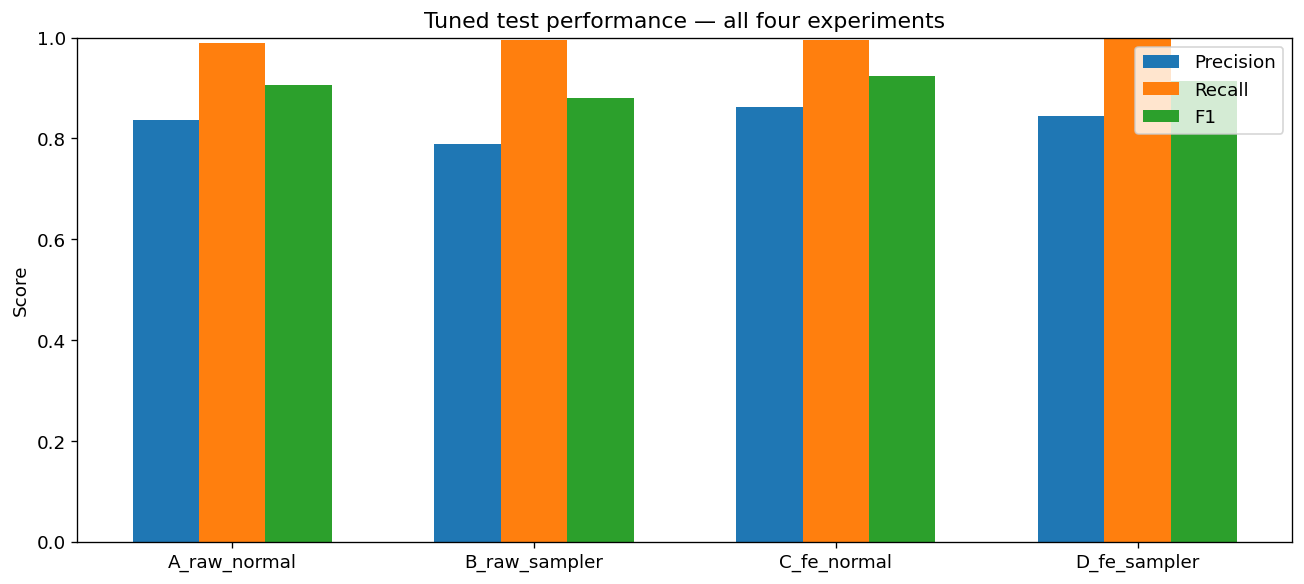

In [44]:
metrics_plot  = ["tuned_test_precision","tuned_test_recall","tuned_test_f1"]
metric_labels = ["Precision","Recall","F1"]
x = np.arange(len(comparison_df["model"])); width = 0.22
plt.figure(figsize=(11, 5))
for i, metric in enumerate(metrics_plot):
    plt.bar(x + i*width, comparison_df[metric], width, label=metric_labels[i])
plt.xticks(x + width, comparison_df["model"])
plt.ylabel("Score"); plt.title("Tuned test performance — all four experiments")
plt.legend(); plt.ylim(0, 1); plt.tight_layout(); plt.show()


## Expected cost comparison

In [ ]:
import matplotlib.pyplot as plt

def plot_weighted_cost(comparison_df, fn_weight=10, fp_weight=1, title_suffix=""):
    df = comparison_df.copy()
    df["weighted_cost"] = df["fn"] * fn_weight + df["fp"] * fp_weight
    df = df.sort_values("weighted_cost")

    plt.figure(figsize=(9, 5))
    bars = plt.bar(df["model"], df["weighted_cost"])

    plt.title(f"Weighted misclassification cost by variant ({fn_weight}:{fp_weight} ratio){title_suffix}")
    plt.ylabel("Weighted misclassification cost")

    plt.bar_label(
        bars,
        labels=[f"{v:.0f}" for v in df["weighted_cost"]],
        padding=3
    )

    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

# Example
plot_weighted_cost(comparison_df, fn_weight=10, fp_weight=1)

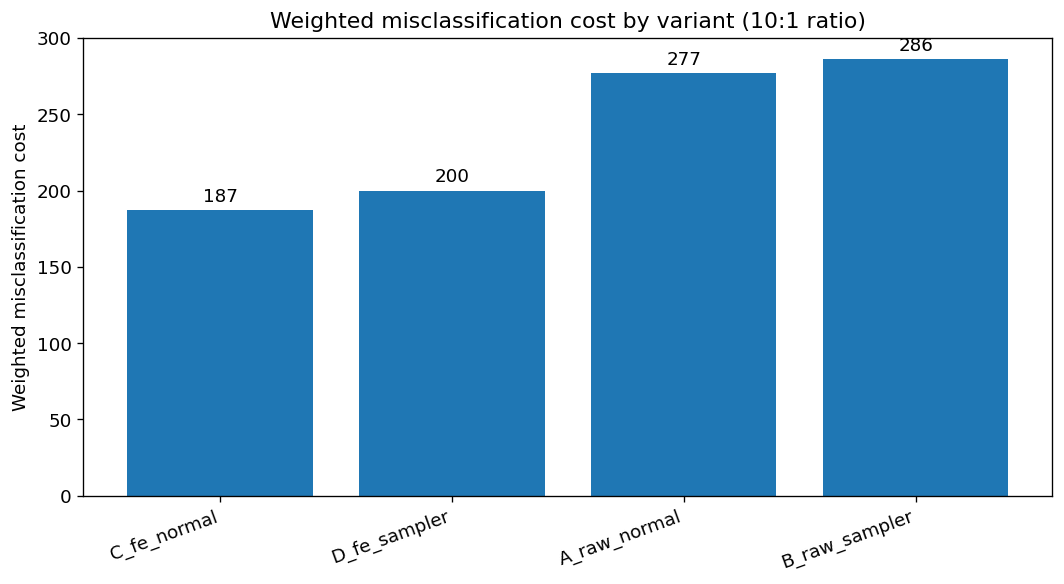

In [45]:
import matplotlib.pyplot as plt

cost_plot_df = comparison_df.sort_values("tuned_expected_cost")

plt.figure(figsize=(9, 5))

bars = plt.bar(
    cost_plot_df["model"],
    cost_plot_df["tuned_expected_cost"]
)

plt.title("Weighted misclassification cost by variant (10:1 ratio)")
plt.ylabel("Weighted misclassification cost")

plt.bar_label(
    bars,
    labels=[f"{v:.0f}" for v in cost_plot_df["tuned_expected_cost"]],
    padding=3
)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Threshold performance plot

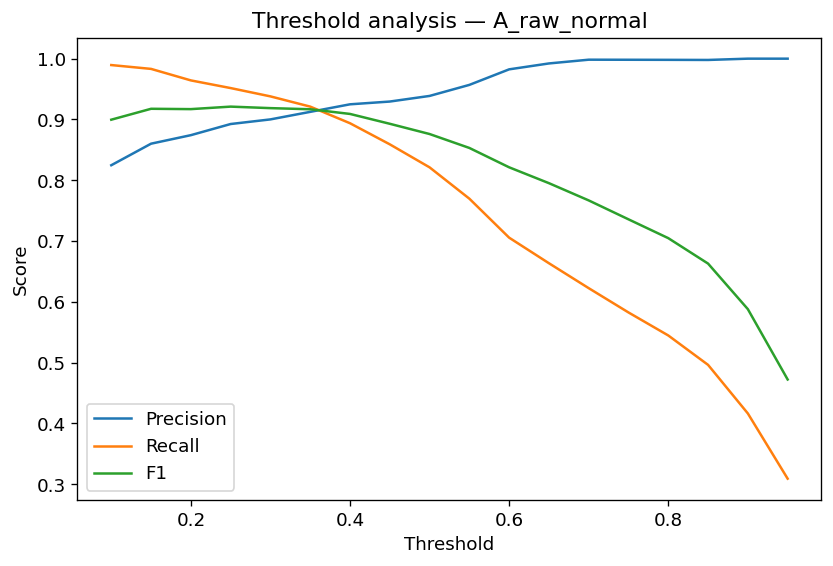

In [46]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["precision"], label="Precision")
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["recall"],    label="Recall")
plt.plot(threshold_results_A_raw_normal["threshold"],
         threshold_results_A_raw_normal["f1"],        label="F1")
plt.title("Threshold analysis — A_raw_normal")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.legend(); plt.show()


## Tuned confusion matrices

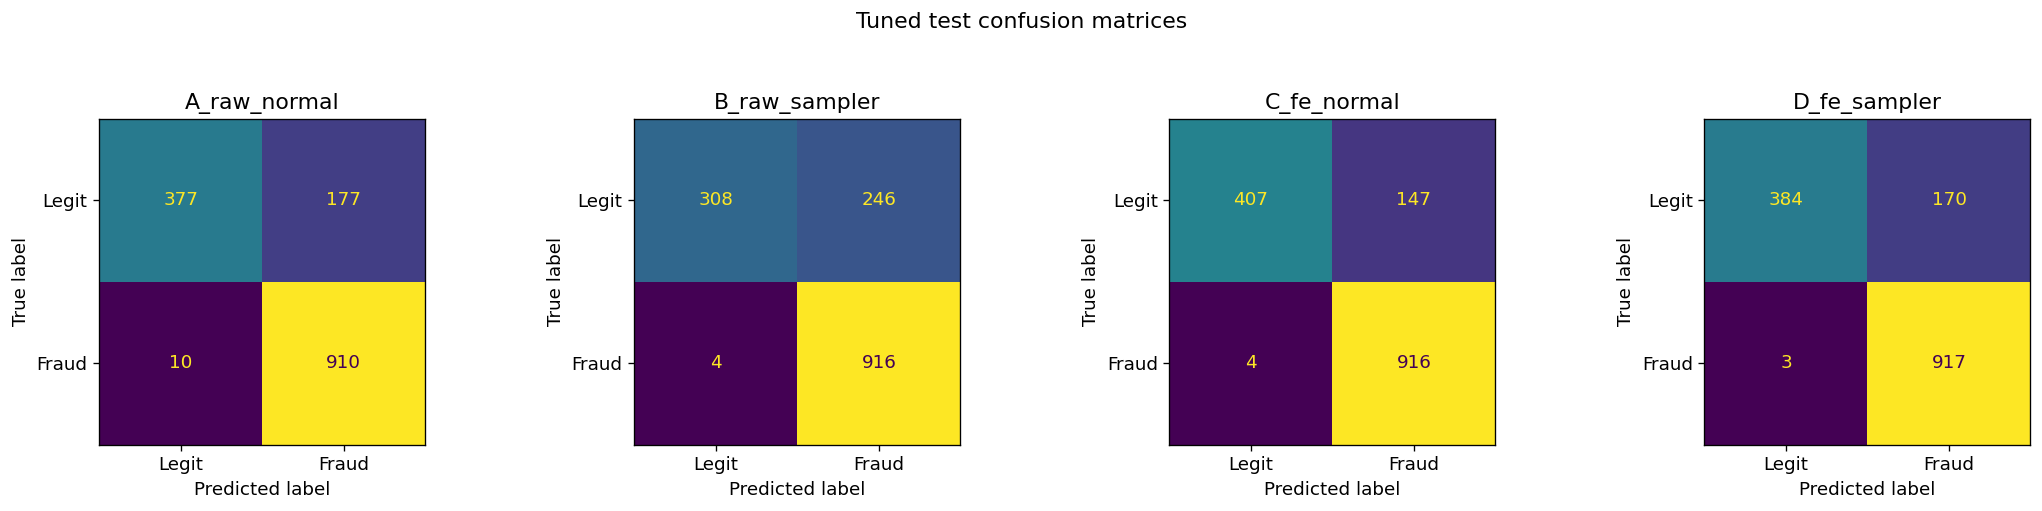

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (cm, title_) in zip(axes, [(tuned_cm_A_raw_normal, "A_raw_normal"), (tuned_cm_B_raw_sampler, "B_raw_sampler"), (tuned_cm_C_fe_normal, "C_fe_normal"), (tuned_cm_D_fe_sampler, "D_fe_sampler")]):
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(title_)
plt.suptitle("Tuned test confusion matrices", y=1.05)
plt.tight_layout(); plt.show()


## Threshold analysis — precision, recall, F1

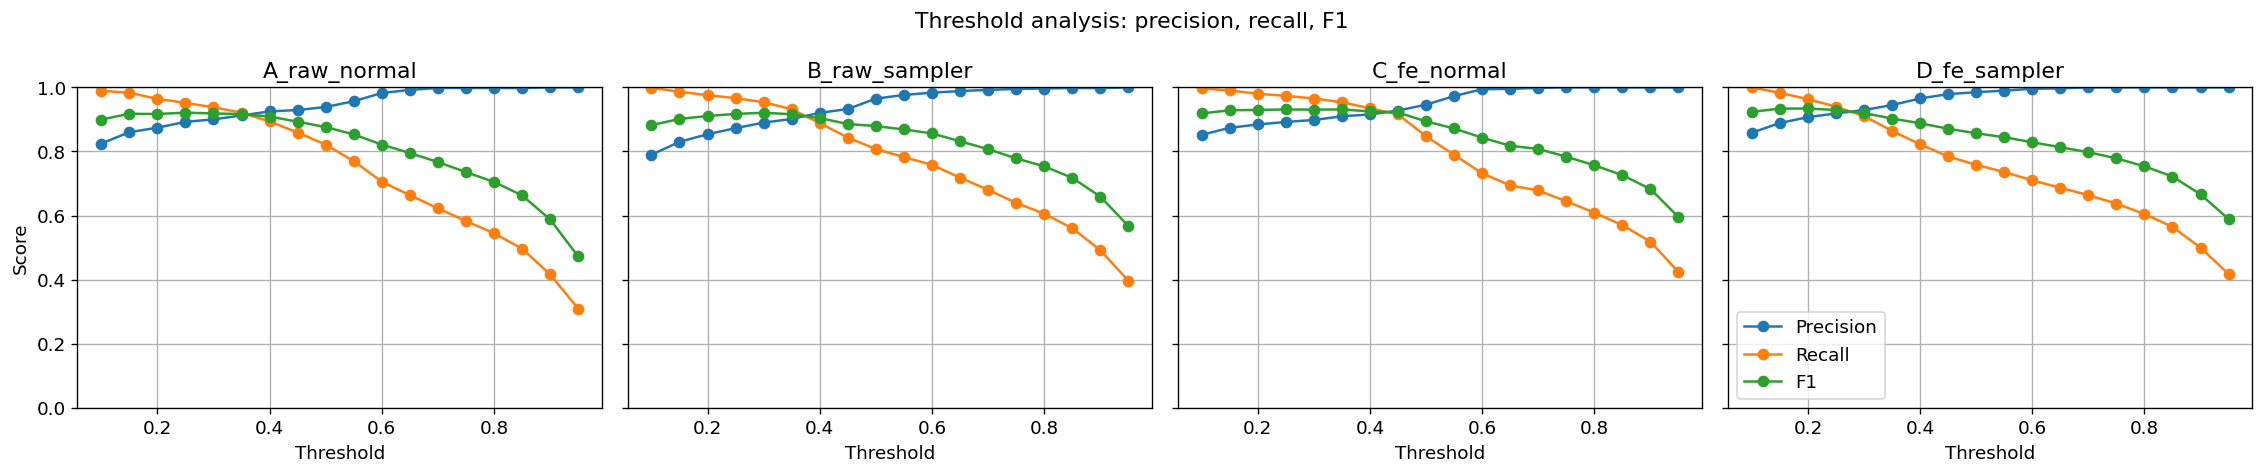

In [48]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=True)
for ax, (df, title_) in zip(axes, [(threshold_results_A_raw_normal, "A_raw_normal"), (threshold_results_B_raw_sampler, "B_raw_sampler"), (threshold_results_C_fe_normal, "C_fe_normal"), (threshold_results_D_fe_sampler, "D_fe_sampler")]):
    ax.plot(df["threshold"], df["precision"], marker="o", label="Precision")
    ax.plot(df["threshold"], df["recall"],    marker="o", label="Recall")
    ax.plot(df["threshold"], df["f1"],        marker="o", label="F1")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylim(0, 1); ax.grid(True)
axes[0].set_ylabel("Score"); axes[-1].legend(loc="best")
plt.suptitle("Threshold analysis: precision, recall, F1")
plt.tight_layout(); plt.show()


## Expected cost by threshold

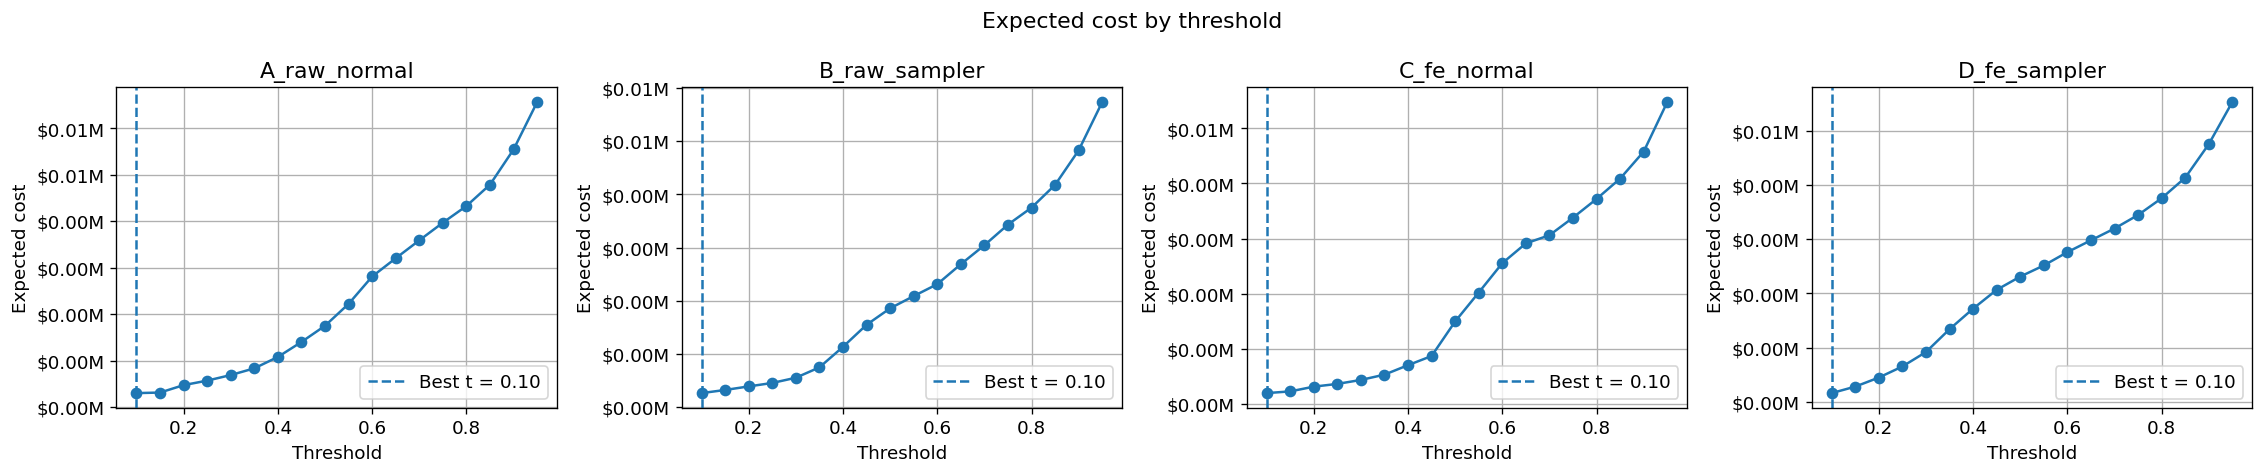

In [49]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4), sharey=False)
for ax, (df, title_) in zip(axes, [(cost_df_A_raw_normal, "A_raw_normal"), (cost_df_B_raw_sampler, "B_raw_sampler"), (cost_df_C_fe_normal, "C_fe_normal"), (cost_df_D_fe_sampler, "D_fe_sampler")]):
    df_sorted = df.sort_values("threshold")
    best_row  = df.loc[df["expected_cost"].idxmin()]
    ax.plot(df_sorted["threshold"], df_sorted["expected_cost"], marker="o")
    ax.axvline(best_row["threshold"], linestyle="--",
               label=f"Best t = {best_row['threshold']:.2f}")
    ax.set_title(title_); ax.set_xlabel("Threshold"); ax.set_ylabel("Expected cost")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x/1_000_000:.2f}M"))
    ax.grid(True); ax.legend()
plt.suptitle("Expected cost by threshold")
plt.tight_layout(); plt.show()


## Precision-Recall curves

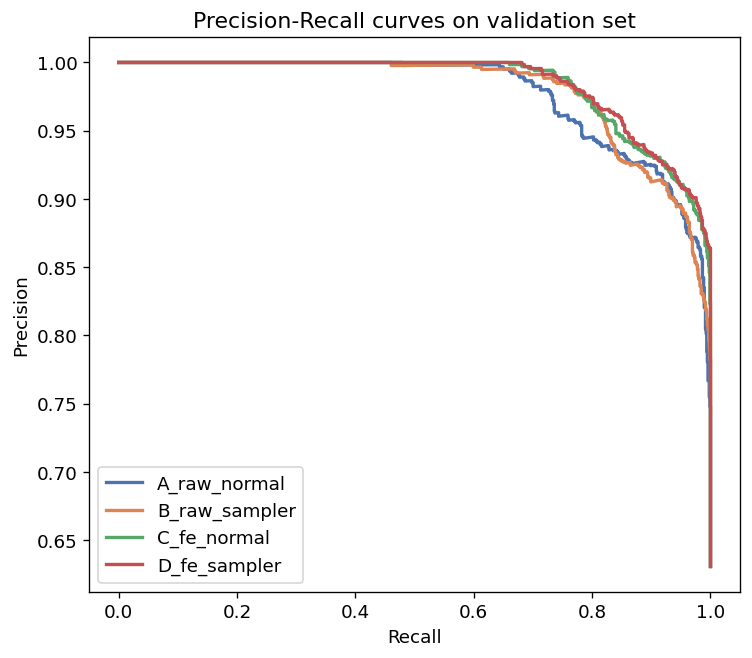

In [50]:
from sklearn.metrics import precision_recall_curve
p_0, r_0, _ = precision_recall_curve(val_y_A_raw_normal, val_p_A_raw_normal)
p_1, r_1, _ = precision_recall_curve(val_y_B_raw_sampler, val_p_B_raw_sampler)
p_2, r_2, _ = precision_recall_curve(val_y_C_fe_normal, val_p_C_fe_normal)
p_3, r_3, _ = precision_recall_curve(val_y_D_fe_sampler, val_p_D_fe_sampler)
plt.figure(figsize=(7, 6))
plt.plot(r_0, p_0, color='#4C72B0', lw=2, label="A_raw_normal")
plt.plot(r_1, p_1, color='#DD8452', lw=2, label="B_raw_sampler")
plt.plot(r_2, p_2, color='#55A868', lw=2, label="C_fe_normal")
plt.plot(r_3, p_3, color='#C44E52', lw=2, label="D_fe_sampler")
plt.title("Precision-Recall curves on validation set")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(); plt.show()


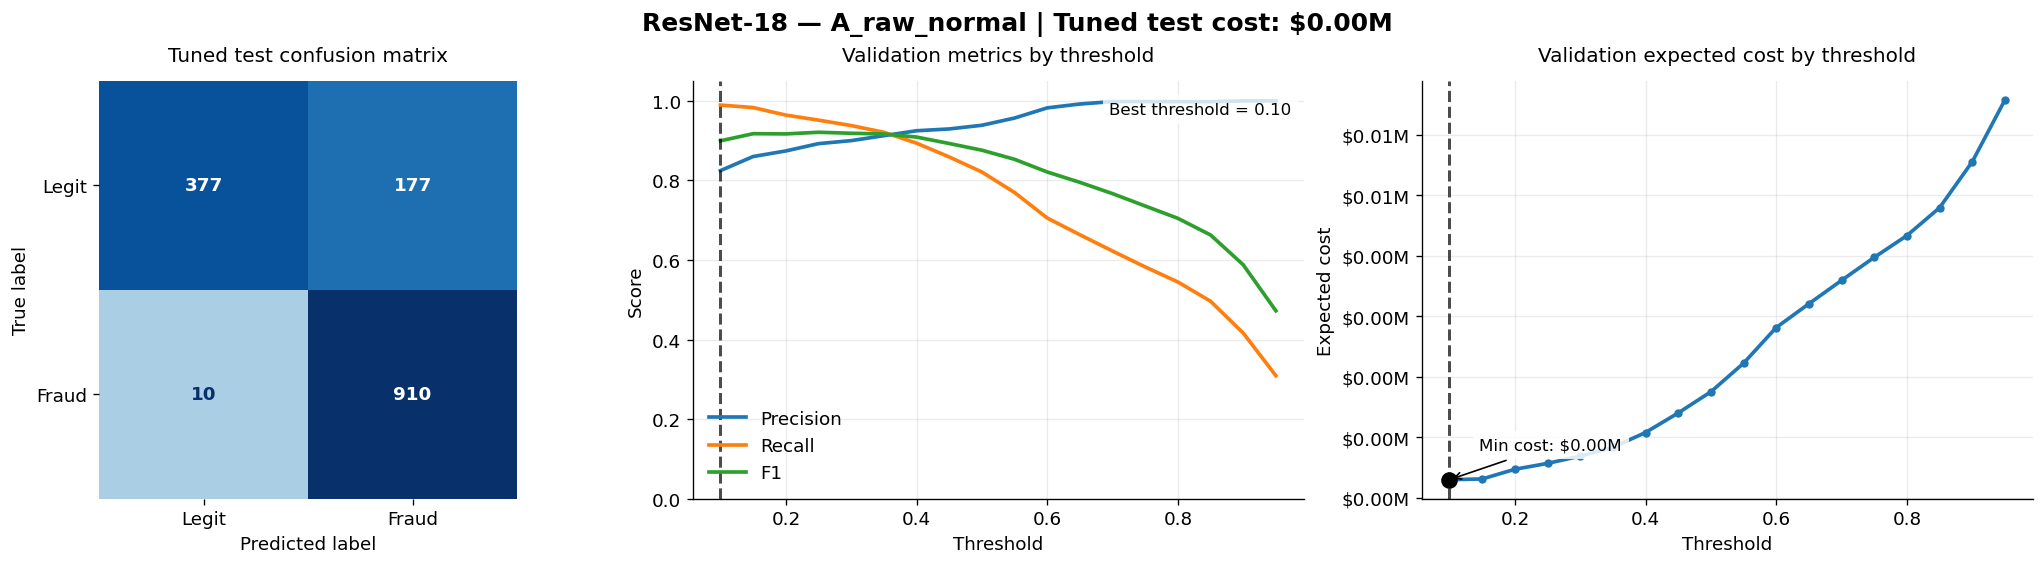

In [51]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_A_raw_normal,
    threshold_results=threshold_results_A_raw_normal,
    cost_df=cost_df_A_raw_normal,
    model_name="ResNet-18 — A_raw_normal",
    save_path=RESULTS_BASE / "diagnostics_A_raw_normal.png",
)


ResNet-18 A_raw_normal selects threshold 0.10 and achieves a tuned test cost of about $0.59M. It detects 910 fraud cases and misses only 10, while still correctly identifying 377 legitimate cases. Unlike the weaker unimodal models, it does not collapse into an all-fraud classifier, showing that multimodal fusion provides stronger class separation.

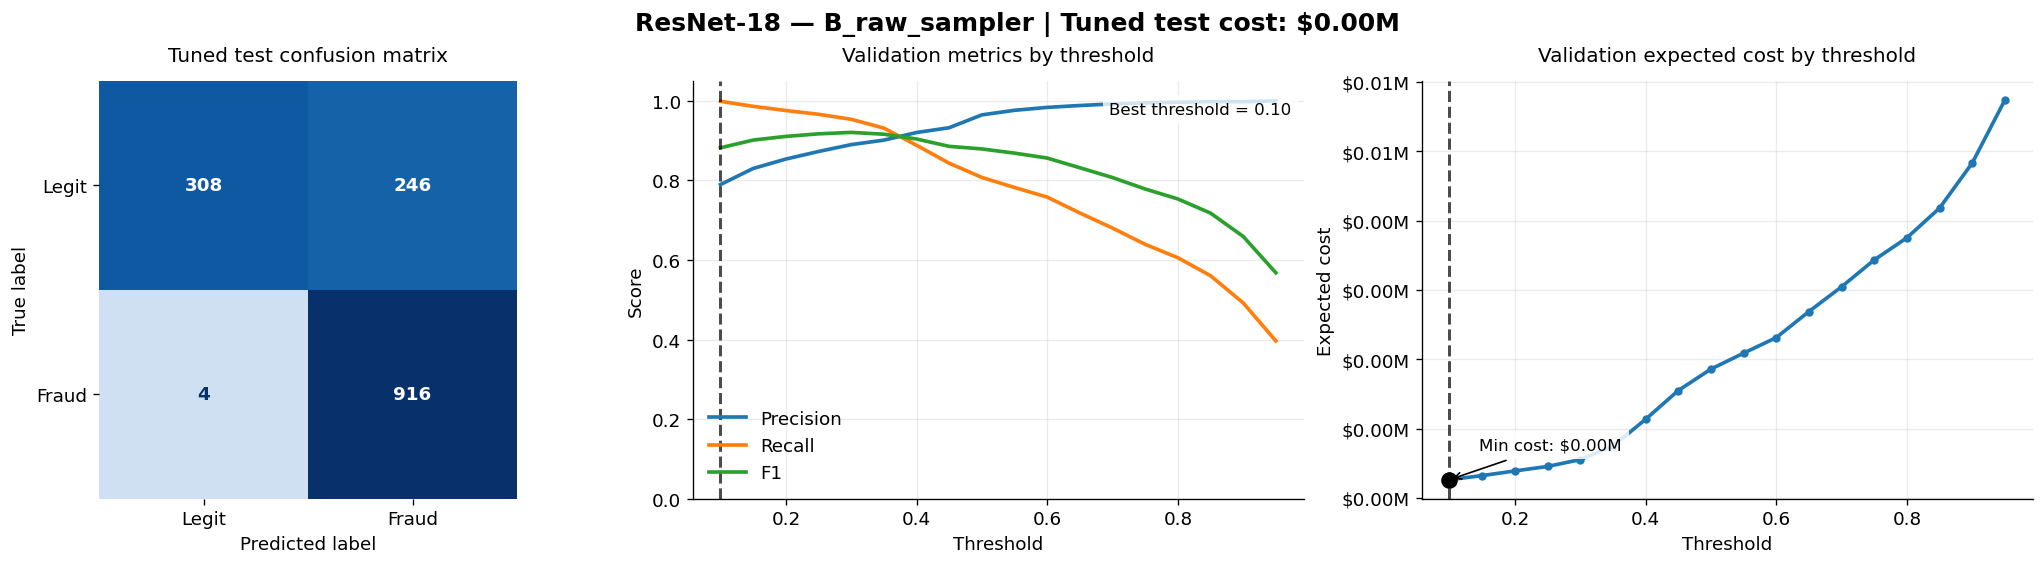

In [52]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_B_raw_sampler,
    threshold_results=threshold_results_B_raw_sampler,
    cost_df=cost_df_B_raw_sampler,
    model_name="ResNet-18 — B_raw_sampler",
    save_path=RESULTS_BASE / "diagnostics_B_raw_sampler.png",
)


ResNet-18 B_raw_sampler achieves a tuned test cost of about $0.32M. It misses only 4 fraud cases, compared with 10 for A_raw_normal, but produces more false positives. Because false negatives are much more expensive, this trade-off lowers the total cost. The model remains meaningful because it still correctly identifies 308 legitimate cases.

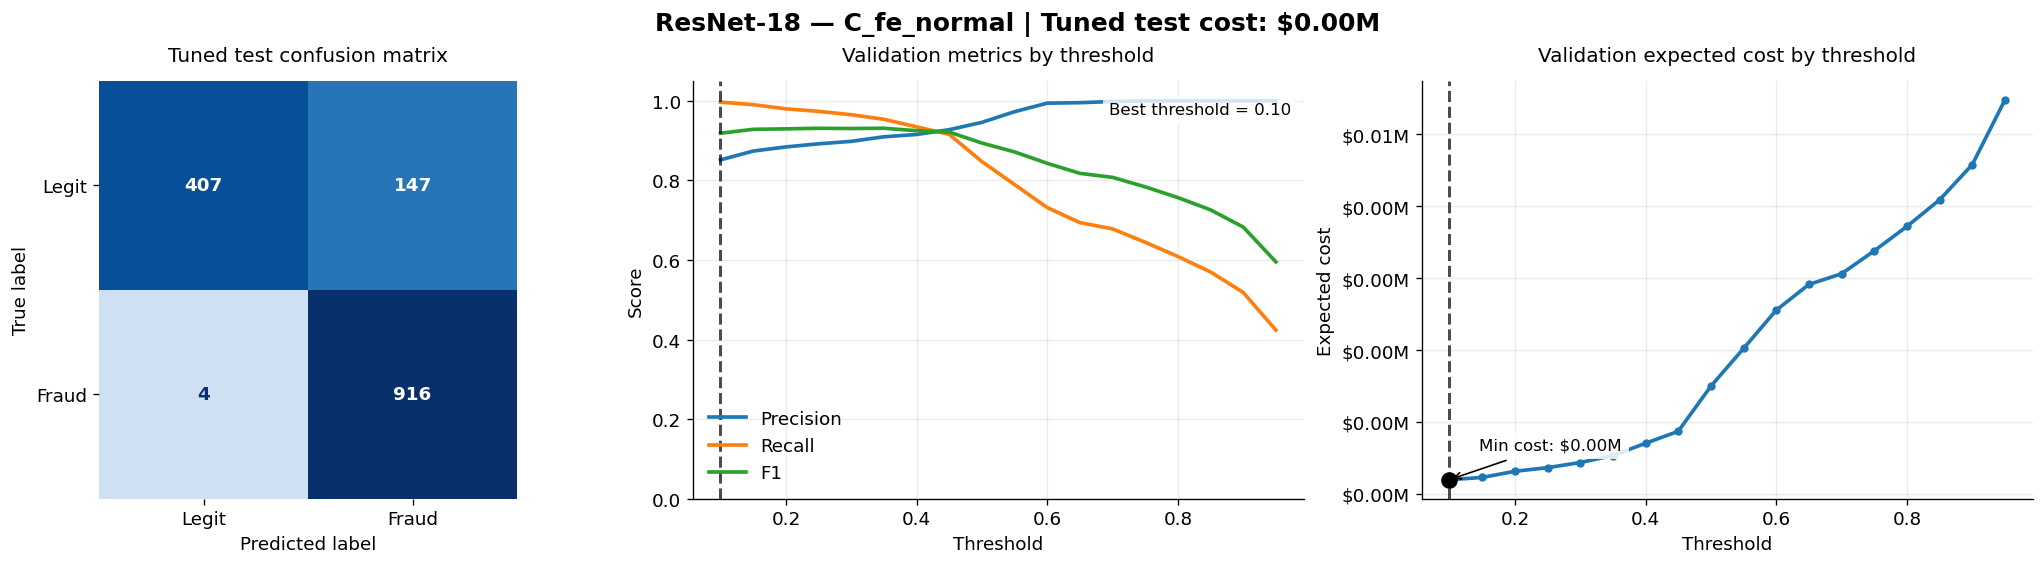

In [53]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_C_fe_normal,
    threshold_results=threshold_results_C_fe_normal,
    cost_df=cost_df_C_fe_normal,
    model_name="ResNet-18 — C_fe_normal",
    save_path=RESULTS_BASE / "diagnostics_C_fe_normal.png",
)


ResNet-18 C_fe_normal achieves a tuned test cost of about $0.27M. It misses only 4 fraud cases and correctly identifies 407 legitimate cases. Compared with the raw-feature multimodal models, engineered features reduce false positives while keeping fraud recall very high. This makes C_fe_normal one of the strongest multimodal ResNet variants.

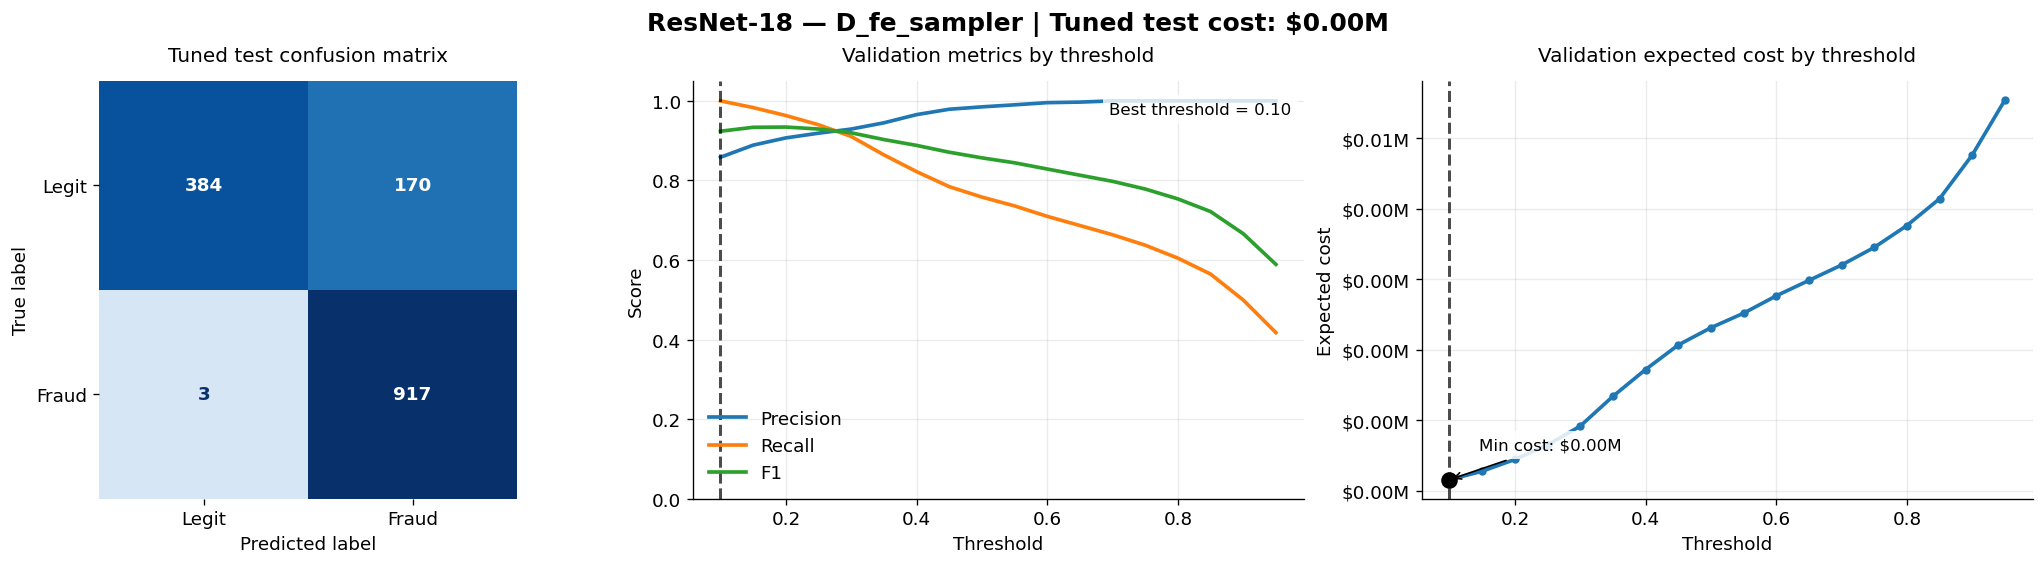

In [54]:
plot_model_diagnostics_pretty(
    cm=tuned_cm_D_fe_sampler,
    threshold_results=threshold_results_D_fe_sampler,
    cost_df=cost_df_D_fe_sampler,
    model_name="ResNet-18 — D_fe_sampler",
    save_path=RESULTS_BASE / "diagnostics_D_fe_sampler.png",
)


ResNet-18 D_fe_sampler achieves the lowest tuned test cost, about $0.23M. It misses only 3 fraud cases and correctly identifies 384 legitimate cases. Compared with C_fe_normal, it accepts slightly more false positives but reduces false negatives, which is beneficial under the cost function. This makes it the best ResNet-18 multimodal variant from a cost-sensitive perspective.

## Training curves

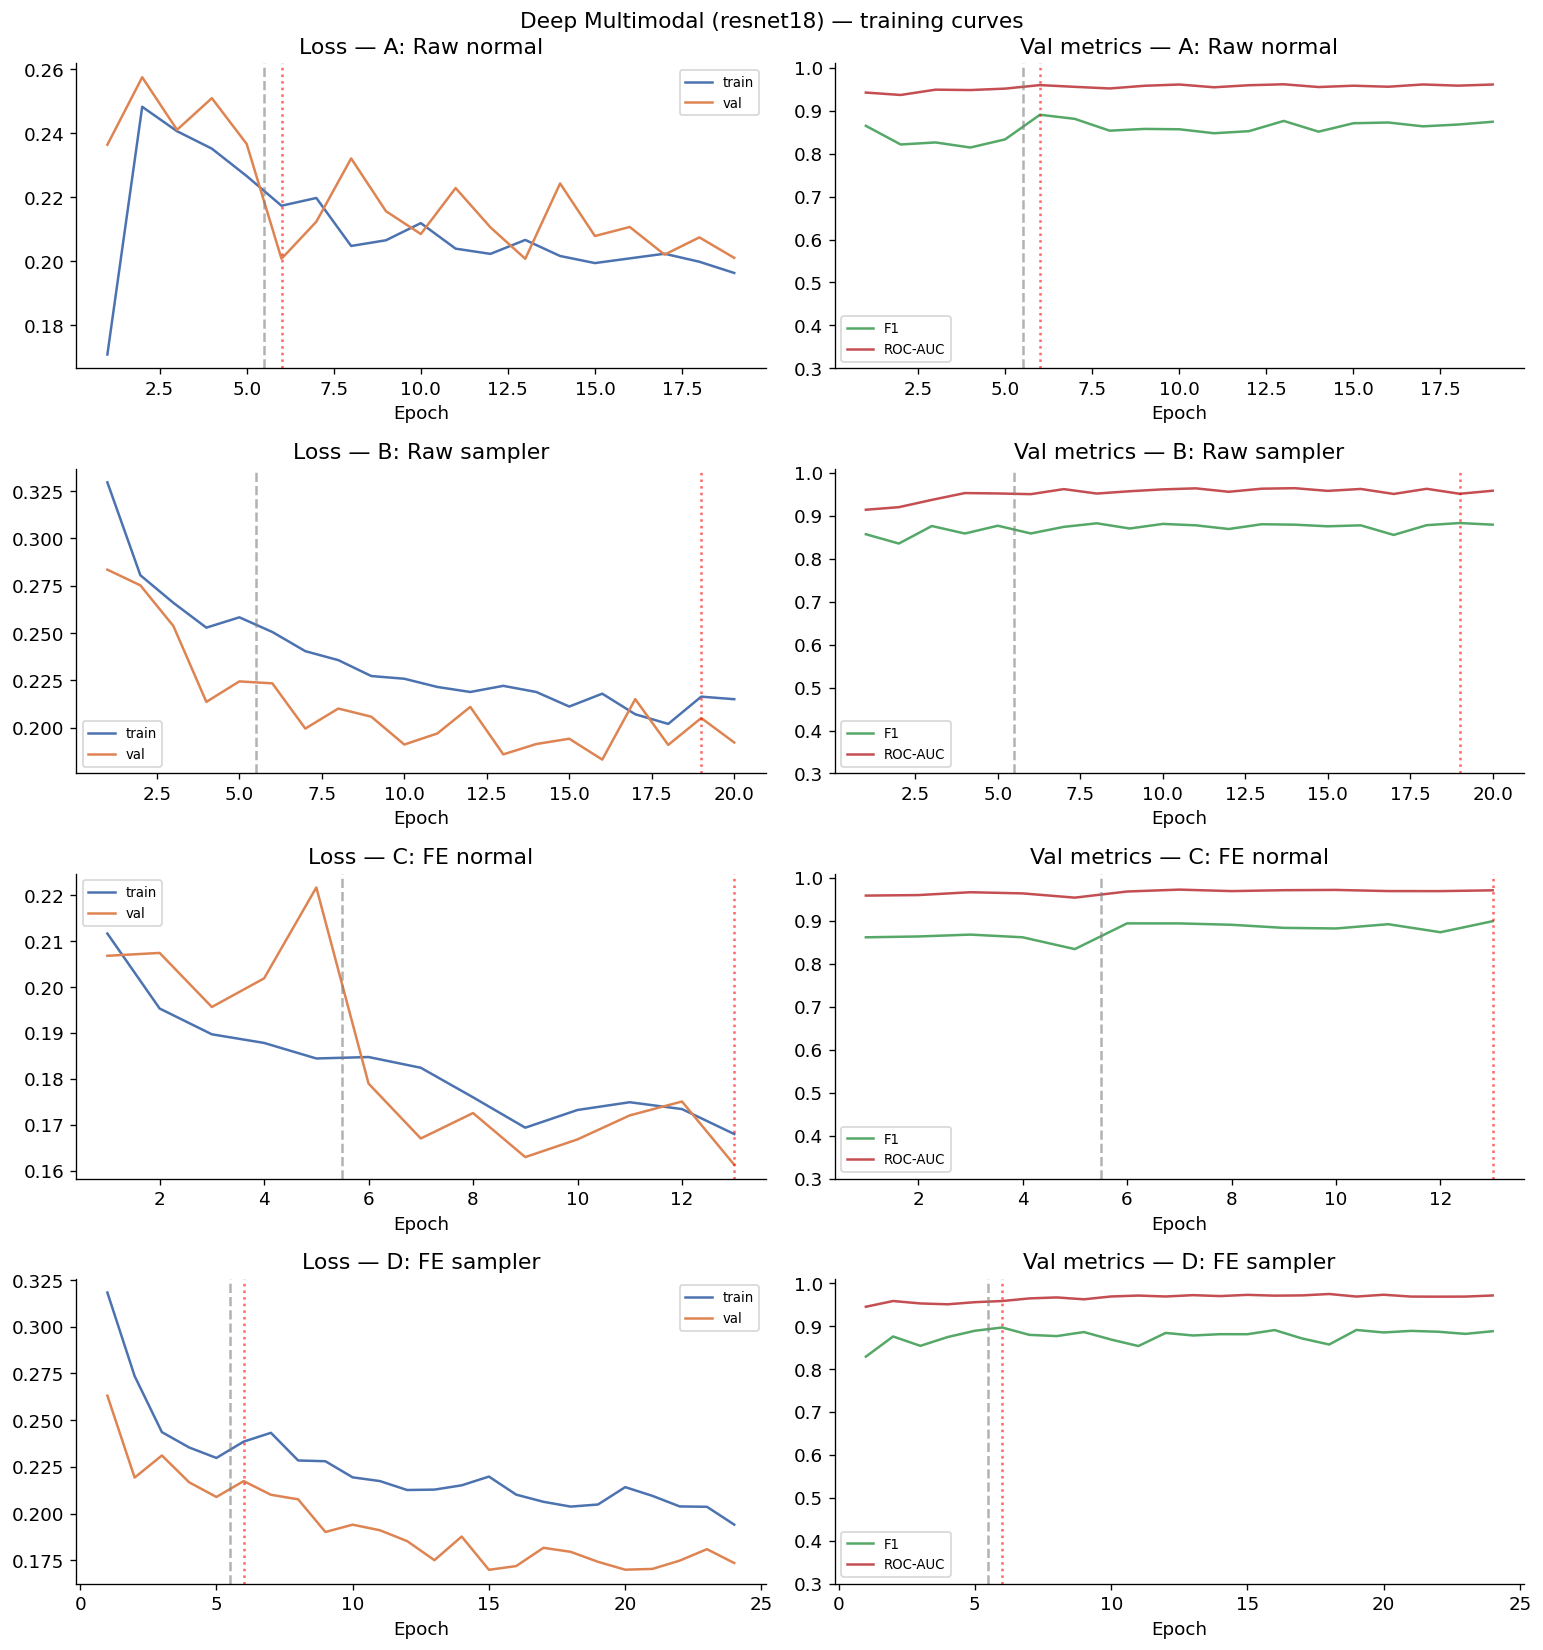

In [55]:
fig, axes = plt.subplots(4, 2, figsize=(13, 14))
labels_all = ["A: Raw normal","B: Raw sampler","C: FE normal","D: FE sampler"]
for row, (exp_id, label) in enumerate(zip(EXP_DIRS.keys(), labels_all)):
    hist_path = EXP_DIRS[exp_id] / "training_history.csv"
    if not hist_path.exists():
        print(f"No history for {exp_id}"); continue
    hist = pd.read_csv(hist_path)
    if "epoch_global" not in hist.columns:
        hist["epoch_global"] = range(1, len(hist)+1)
    ep      = hist["epoch_global"]
    best_ep = ep.iloc[hist["val_f1"].dropna().idxmax()] if not hist["val_f1"].dropna().empty else None

    axes[row,0].plot(ep, hist["train_loss"], label="train", color="#4C72B0")
    axes[row,0].plot(ep, hist["val_loss"],   label="val",   color="#DD8452")
    axes[row,0].set_title(f"Loss — {label}"); axes[row,0].legend(fontsize=8)

    axes[row,1].plot(ep, hist["val_f1"],      label="F1",      color="#55A868")
    axes[row,1].plot(ep, hist["val_roc_auc"], label="ROC-AUC", color="#C44E52")
    axes[row,1].set_ylim(0.3, 1.01)
    axes[row,1].set_title(f"Val metrics — {label}"); axes[row,1].legend(fontsize=8)

    for ax in axes[row]:
        ax.axvline(x=STAGE1_EPOCHS+0.5, color="gray", linestyle="--", alpha=0.6, label="stage 1→2")
        if best_ep is not None:
            ax.axvline(x=best_ep, color="red", linestyle=":", alpha=0.6, label="best val F1")
        ax.set_xlabel("Epoch"); ax.spines[["top","right"]].set_visible(False)

fig.suptitle(f"Deep Multimodal ({BACKBONE}) — training curves", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Subgroup analysis by combo_type

The key thesis diagnostic. Image-only models scored tab1_img0 F1 ≈ 0.30.
Multimodal fusion should recover this group substantially.


In [56]:
results = [
    {"id":"A_raw_normal",  "sg":sg_A_raw_normal,  "threshold":best_threshold_A_raw_normal,  "y_true":test_y_A_raw_normal,  "y_prob":test_p_A_raw_normal},
    {"id":"B_raw_sampler", "sg":sg_B_raw_sampler, "threshold":best_threshold_B_raw_sampler, "y_true":test_y_B_raw_sampler, "y_prob":test_p_B_raw_sampler},
    {"id":"C_fe_normal",   "sg":sg_C_fe_normal,   "threshold":best_threshold_C_fe_normal,   "y_true":test_y_C_fe_normal,   "y_prob":test_p_C_fe_normal},
    {"id":"D_fe_sampler",  "sg":sg_D_fe_sampler,  "threshold":best_threshold_D_fe_sampler,  "y_true":test_y_D_fe_sampler,  "y_prob":test_p_D_fe_sampler},
]
labels_all = [r["id"] for r in results]


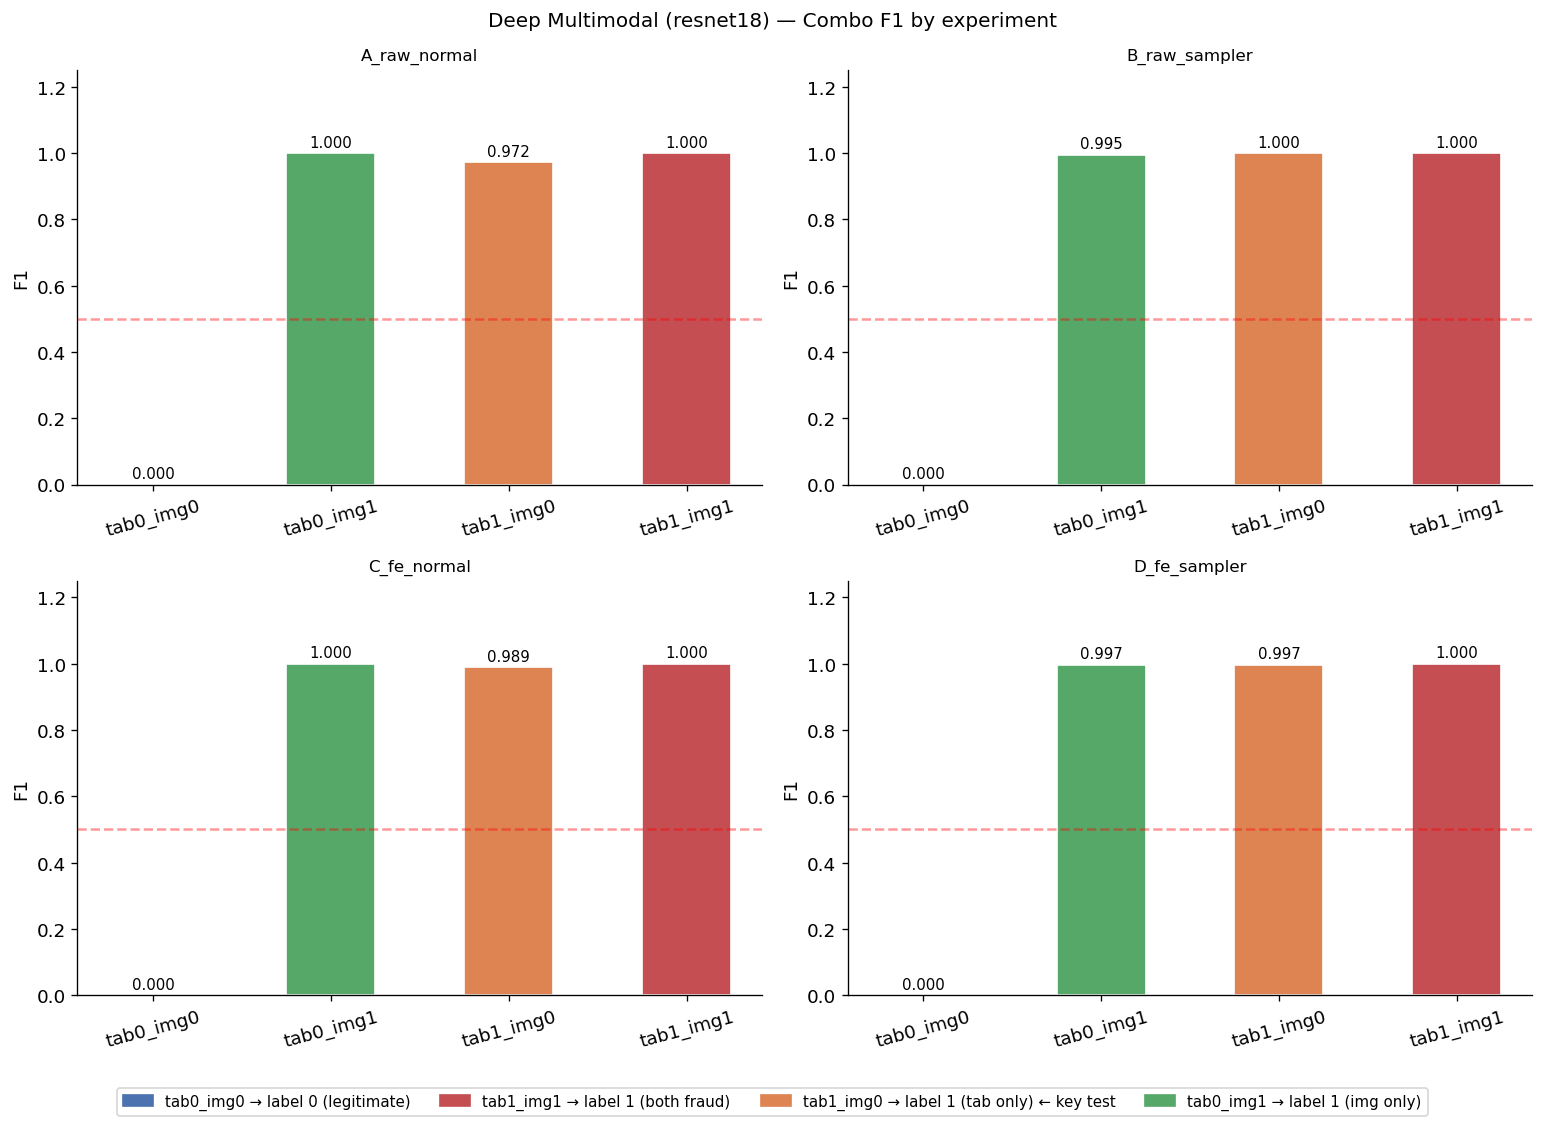

,A_raw_normal,B_raw_sampler,C_fe_normal,D_fe_sampler
combo_type,,,,
tab0_img0,0.000,0.000,0.000,0.000
tab0_img1,1.000,0.995,1.000,0.997
tab1_img0,0.972,1.000,0.989,0.997
tab1_img1,1.000,1.000,1.000,1.000


In [57]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, r, label in zip(axes.flat, results, labels_all):
    sg   = r["sg"]
    clrs = [COMBO_COLOURS.get(c,"gray") for c in sg["combo_type"]]
    bars = ax.bar(sg["combo_type"], sg["f1"], color=clrs, edgecolor="white", width=0.5)
    for bar, val in zip(bars, sg["f1"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_ylim(0, 1.25); ax.set_title(label, fontsize=10)
    ax.axhline(0.5, color="red", linestyle="--", alpha=0.4)
    ax.set_ylabel("F1"); ax.tick_params(axis="x", rotation=15)
    ax.spines[["top","right"]].set_visible(False)
fig.legend(handles=[
    Patch(color="#4C72B0", label="tab0_img0 → label 0 (legitimate)"),
    Patch(color="#C44E52", label="tab1_img1 → label 1 (both fraud)"),
    Patch(color="#DD8452", label="tab1_img0 → label 1 (tab only) ← key test"),
    Patch(color="#55A868", label="tab0_img1 → label 1 (img only)"),
], loc="lower center", ncol=4, bbox_to_anchor=(0.5,-0.05), fontsize=9)
fig.suptitle(f"Deep Multimodal ({BACKBONE}) — Combo F1 by experiment", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_BASE / "subgroup_combo.png", dpi=150, bbox_inches="tight")
plt.show()
sg_cmp = pd.concat([
    r["sg"].set_index("combo_type")[["f1"]].rename(columns={"f1":r["id"]})
    for r in results], axis=1).round(3)
display(sg_cmp)
sg_cmp.to_csv(RESULTS_BASE / "subgroup_comparison.csv")


## Per-combo diagnostics

In [58]:
from sklearn.metrics import f1_score, accuracy_score

def combo_metrics_fixed(res):
    df   = res["pred_df"] if "pred_df" in res else pd.DataFrame(
           {"y_true": res["y_true"], "y_prob": res["y_prob"],
            "y_pred": (res["y_prob"] >= res["threshold"]).astype(int)})
    rows = {}
    for combo, g in df.groupby("combo_type"):
        y_true = g["y_true"]; y_pred = g["y_pred"]
        acc    = accuracy_score(y_true, y_pred)
        if combo == "tab0_img0":
            legit_f1 = f1_score(y_true, y_pred, pos_label=0, zero_division=0)
            fp       = ((y_true==0)&(y_pred==1)).sum()
            n_legit  = (y_true==0).sum()
            fpr      = fp/n_legit if n_legit > 0 else float("nan")
            rows["tab0_img0_acc"] = acc; rows["tab0_img0_legit_f1"] = legit_f1; rows["tab0_img0_fpr"] = fpr
        elif combo == "tab1_img0":
            rows["tab1_img0_f1"] = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
            rows["tab1_img0_acc"] = acc
        else:
            rows[f"{combo}_acc"] = acc
    return rows


In [59]:
summary_rows = []
for res, feat, samp in [
    (results[0], "Raw",        "No"),
    (results[1], "Raw",        "Yes"),
    (results[2], "Engineered", "No"),
    (results[3], "Engineered", "Yes"),
]:
    m = {"accuracy": val_metrics_A_raw_normal["accuracy"],
         "precision": tuned_metrics_A_raw_normal["precision"],
         "recall": tuned_metrics_A_raw_normal["recall"],
         "f1": tuned_metrics_A_raw_normal["f1"],
         "roc_auc": val_metrics_A_raw_normal["roc_auc"]}
    m = {k: (test_metrics_A_raw_normal if res["id"]=="A_raw_normal"
         else test_metrics_B_raw_sampler if res["id"]=="B_raw_sampler"
         else test_metrics_C_fe_normal if res["id"]=="C_fe_normal"
         else test_metrics_D_fe_sampler)[k] for k in ["accuracy","precision","recall","f1","roc_auc"]}
    combo = combo_metrics_fixed(res)
    summary_rows.append({
        "Experiment": res["id"], "Features": feat, "Sampler": samp,
        "Threshold": res["threshold"],
        "Accuracy": m["accuracy"], "Precision": m["precision"],
        "Recall": m["recall"], "F1": m["f1"], "ROC-AUC": m["roc_auc"],
        "tab0_img0 Legit F1": combo.get("tab0_img0_legit_f1"),
        "tab0_img0 FPR":      combo.get("tab0_img0_fpr"),
        "tab1_img0 Fraud F1": combo.get("tab1_img0_f1"),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df.round(4))


KeyError: 'combo_type'

## Final choice

In [ ]:
comparison_df.to_csv(RESULTS_BASE / "comparison.csv", index=False)
print("Saved comparison to:", RESULTS_BASE / "comparison.csv")
final_choice_df = comparison_df.sort_values("tuned_expected_cost").copy()
print("Best variant:", final_choice_df.iloc[0]["model"])
final_choice_df


Saved comparison to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_deep_resnet18\comparison.csv
Best variant: D_fe_sampler


,model,val_f1,val_roc_auc,val_pr_auc,test_f1,test_roc_auc,test_pr_auc,best_threshold,tuned_test_precision,tuned_test_recall,tuned_test_f1,tuned_expected_cost
3,D_fe_sampler,0.856803,0.974388,0.984765,0.874469,0.979528,0.987774,0.1,0.843606,0.996739,0.913802,235000
2,C_fe_normal,0.894065,0.972709,0.983828,0.906052,0.979169,0.987336,0.1,0.861712,0.995652,0.923853,273500
1,B_raw_sampler,0.879222,0.964175,0.979105,0.877732,0.964178,0.979137,0.1,0.788296,0.995652,0.879923,323000
0,A_raw_normal,0.876052,0.961381,0.977084,0.883314,0.967052,0.980079,0.1,0.837167,0.989130,0.906826,588500
